# Imports and setup


In [1]:
## Image viewing
import os
from pathlib import Path
import uuid
import math

from scipy.special import expit

from tqdm.auto import tqdm

import navis


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix
import itertools

import colorcet as cc

IBMblue = "648FFF"
IBMpurple = "785EF0"
IBMhotpink = "DC267F"
IBMorange = "FE6100"
IBMyellow = "FFB000"

import imagej

# FIJI_APP = "/home/william-zheng/Downloads/Fiji.app"
# PROJECT_DIR = "/home/william-zheng/Documents/Programming/Python/NeuroInformatics/summer_2026/neuroinfo_fruitfly"
FIJI_APP = "/Users/vuhepola/Desktop/Fiji"
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
FISBe_DIR = DATA_DIR / "FISBe"
FlyLight_DIR = DATA_DIR / "FlyLight"
FANC_DIR = DATA_DIR / "FANC"

print(FIJI_APP)
print(PROJECT_DIR)
print(DATA_DIR)
print(FISBe_DIR)
print(FlyLight_DIR)
print(FANC_DIR)

/Users/vuhepola/Desktop/Fiji
/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfly
/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfly/data
/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfly/data/FISBe
/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfly/data/FlyLight
/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfly/data/FANC


### Helper functions


In [2]:
# Assuming 'scores' is your NBLAST result DataFrame
# Rows = Queries, Columns = Targets

def get_top_n_matches(nblast_scores, n=5):
    """
    Returns a DataFrame showing the top N matches for each query.
    """
    # Get the indices of the top N columns for each row
    # axis=1 sorts across columns
    top_indices = np.argsort(nblast_scores.values, axis=1)[:, ::-1][:, :n]
    
    # Create a new DataFrame for results
    top_matches = pd.DataFrame(index=nblast_scores.index)
    
    for i in range(n):
        # Add the Target ID
        top_matches[f'rank_{i+1}_id'] = nblast_scores.columns[top_indices[:, i]]
        # Add the corresponding NBLAST score
        top_matches[f'rank_{i+1}_score'] = nblast_scores.values[np.arange(nblast_scores.shape[0]), top_indices[:, i]]
        
        # print(f"rank_{i+1}")
        
    return top_matches

def get_k_colors(k, cmap_name='hsv'):
    # Fetch the colormap object
    cmap = plt.colormaps[cmap_name]
    
    # Linearly space k points between 0.0 and 1.0
    colors = [cmap(i) for i in np.linspace(0, 1, k)]
    return colors

def confidence_weighted_vote(predictions, confidences):
    """
    Computes the winning class based on confidence weights.
    
    predictions: list/array of predicted class labels (e.g., [0, 1, 0])
    confidences: list/array of confidence scores for each prediction (e.g., [0.9, 0.4, 0.3])
    """
    # Find all unique class labels present in the votes
    unique_classes = np.unique(predictions)
    
    best_class = None
    max_weighted_vote = -np.inf
    
    # Calculate total weight for each class
    for cls in unique_classes:
        # Sum confidences where the prediction matches the current class
        class_weight = np.sum(confidences[predictions == cls])
        
        if class_weight > max_weighted_vote:
            max_weighted_vote = class_weight
            best_class = cls
            
    return best_class, max_weighted_vote

def top_k_infer_lineage_fast(score_matrix, k=1, verbose=False):
    # print(f"k={k}")
    # Get top matches
    top_k = get_top_n_matches(score_matrix, n=k+1)

    # =========================================================
    # OPTIMIZATION 1: Precompute a fast Dictionary mapping
    # =========================================================
    
    id_to_class = {}
    for tid in score_matrix.columns:
        # Get the SWC name
        neuron_name = sorted_target_neurons.idx[tid].name
        
        # FIX: Provide "Unknown" as a fallback if the lookup fails. 
        # This prevents None/NaN (floats) from entering the predictions array!
        id_to_class[tid] = name_to_class.get(neuron_name, "Unknown")
        
    # =========================================================
    # OPTIMIZATION 2: Vectorize the 'actual' class lookups 
    # =========================================================
    # Use a lambda function to explicitly enforce the "Unknown" fallback
    actual_lineage_list = top_k['rank_1_id'].map(
        lambda x: id_to_class.get(x, "Unknown")
    ).astype(str).values
    
    # =========================================================
    # OPTIMIZATION 3: Extract prediction matrices all at once
    # =========================================================
    id_cols = [f'rank_{i}_id' for i in range(2, k+2)]
    score_cols = [f'rank_{i}_score' for i in range(2, k+2)]
    
    # FIX: The lambda guarantees no None/NaN values are generated
    # .astype(str) acts as a final safeguard to ensure the matrix is 100% strings
    classes_matrix = top_k[id_cols].map(
        lambda x: id_to_class.get(x, "Unknown")
    ).astype(str).values
    
    scores_matrix = top_k[score_cols].values
    
    # =========================================================
    # OPTIMIZATION 4: Fast row-iteration with zip
    # =========================================================
    predicted_lineage_list = []
    max_score_list = []
    max_weighted_vote_list = []
    
    for c_row, s_row in zip(classes_matrix, scores_matrix):
        predicted_class, max_weighted_vote = confidence_weighted_vote(c_row, s_row)
        predicted_lineage_list.append(predicted_class)
        max_score_list.append(s_row[0].item())
        max_weighted_vote_list.append(max_weighted_vote)
        
    # print(max_score_list)
        
    return actual_lineage_list, np.array(predicted_lineage_list), max_score_list, max_weighted_vote_list

In [3]:
def evaluate_and_plot_knn(matrix_dict, true_lineages_df, k_values=range(1, 5)):
    """
    Evaluates K-Votes lineage classification accuracy across multiple preprocessed matrices
    and plots a 2x2 performance grid.
    
    Parameters:
    -----------
    matrix_dict : dict
        A dictionary mapping descriptive titles to preprocessed DataFrames:
        e.g., {"Raw": raw_df, "Row Standardized": row_df}
    true_lineages_df : pd.DataFrame
        Metadata reference containing ground truth labels.
    k_values : iterable
        Range of k-values to evaluate.
    """
    fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharey=True, sharex=True)
    axes = axes.flatten()
    
    # Iterate through each preprocessed matrix
    for i, (title, matrix) in enumerate(matrix_dict.items()):
        mean_accuracy_list = []
        
        for k in tqdm(k_values, desc=f"Tuning {title}"):
            # Assuming top_k_infer_lineage_fast is loaded in your namespace
            actual, predicted, _, _ = top_k_infer_lineage_fast(matrix, k)
            
            # Handle possible None/NaN values safely
            correct_count = sum(1 for act, pred in zip(actual, predicted) if act == pred and pred is not None)
            accuracy = (correct_count / len(actual)) * 100
            mean_accuracy_list.append(accuracy)
            
        best_idx = np.argmax(mean_accuracy_list)
        best_k = list(k_values)[best_idx]
        best_score = mean_accuracy_list[best_idx]
        
        print(f"{title} -> Best k = {best_k}, Accuracy: {best_score:.2f}%")
        
        # Plot coordinates
        axes[i].plot(k_values, mean_accuracy_list, marker='o', linestyle='-', color='#1f77b4', linewidth=2.5, markersize=7)
        axes[i].plot(best_k, best_score, marker='*', color='#d62728', markersize=14, label='Peak Accuracy' if i == 0 else "")
        
        # Styling
        axes[i].set_title(title, fontsize=14, fontweight='bold', pad=10)
        axes[i].set_xlabel("k (Nearest Neighbors)", fontsize=11, labelpad=8)
        axes[i].set_ylabel("Classification Accuracy (%)", fontsize=11, labelpad=8)
        axes[i].set_xticks(list(k_values))
        axes[i].grid(True, linestyle='--', alpha=0.5)
        
        if i == 0:
            axes[i].legend(loc='lower right', frameon=True)
            
    # Hide redundant ticks on inner subplots
    for ax in axes:
        ax.label_outer()
        
    fig.suptitle("KNN Lineage Classification Accuracy across NBLAST Preprocessing Variations", 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

In [4]:
# from scipy.stats import norm

# class BayesianNBLASTClassifier:
#     def __init__(self, color_map=None, default_color='gray'):
#         """
#         Class-based Bayesian Maximum a Posteriori (MAP) classifier for neuron lineages.
#         """
#         self.color_map = color_map or {}
#         self.default_color = default_color
#         self.priors = None
#         self.class_distributions = {}  # Stores mean and std deviation per class
#         self.unique_classes = None
        
#     def fit(self, score_matrix, metadata, class_column="classification_system"):
#         """
#         Calculates prior probabilities and fits likelihood distributions for each lineage class.
#         """
#         # Ensure alignment of scores and metadata
#         shared_ids = score_matrix.index.intersection(metadata.index)
#         aligned_meta = metadata.loc[shared_ids]
#         aligned_scores = score_matrix.loc[shared_ids, shared_ids]
        
#         # 1. Compute Class Priors
#         class_counts = aligned_meta[class_column].value_counts(dropna=True)
#         self.priors = class_counts / class_counts.sum()
#         self.unique_classes = self.priors.index.tolist()
        
#         # 2. Fit Likelihood Parameter Distributions (mean & std dev) for each class
#         self.class_distributions = {}
#         for cls in self.unique_classes:
#             # Gather all training neurons belonging to this class
#             class_neuron_ids = aligned_meta[aligned_meta[class_column] == cls].index
            
#             # Extract their cross-scores (excluding self-matches)
#             sub_matrix = aligned_scores.loc[class_neuron_ids, class_neuron_ids]
#             # print(sub_matrix.shape)
#             flat_scores = sub_matrix.values[~np.eye(sub_matrix.shape[0], dtype=bool)]
#             # flat_scores = flat_scores[~np.isnan(flat_scores)]  # Filter out NaNs
            
            
#             # Fit a normal distribution as your likelihood model
#             if len(flat_scores) > 1:
#                 mean, std = norm.fit(flat_scores)
#             else:
#                 mean, std = 0.0, 1.0 # Safe fallback
                
#             self.class_distributions[cls] = {"mean": mean, "std": max(std, 1e-5)}
            
#     def _calculate_likelihood(self, query_id, score_matrix, target_class, metadata, class_column):
#         """Helper to calculate the product of likelihoods for a query against a class."""
#         # Find training targets belonging to the lineage class
#         class_targets = metadata[metadata[class_column] == target_class].index
#         class_targets = class_targets.intersection(score_matrix.columns)
        
#         # Drop the query itself from the target list to prevent self-bias
#         class_targets = class_targets.drop(query_id, errors='ignore')
        
#         if len(class_targets) == 0:
#             return 1e-300  # Return baseline floor if no valid training examples exist
            
#         scores = score_matrix.loc[query_id, class_targets].values
#         scores = scores[~np.isnan(scores)]
        
#         # Retrieve fit distribution parameters
#         mean = self.class_distributions[target_class]["mean"]
#         std = self.class_distributions[target_class]["std"]
        
#         # Calculate likelihood product using normal probability density function (PDF)
#         pdfs = norm.pdf(scores, loc=mean, scale=std)
#         pdfs = np.clip(pdfs, 1e-300, None)  # Prevent complete underflow
        
#         # Log-sum exp transition or direct multiplication depending on size
#         return np.exp(np.sum(np.log(pdfs)))

#     def predict_map(self, query_ids, score_matrix, metadata, class_column="classification_system"):
#         """
#         Executes MAP estimation over a list of query ids.
#         """
#         predictions = []
#         all_posteriors = []
        
#         for q_id in tqdm(query_ids, desc="Bayesian MAP Inferences"):
#             posteriors = {}
#             total_numerator = 0.0
            
#             # 1. Compute Posterior Numerator: Prior * Likelihood Product
#             for cls in self.unique_classes:
#                 prior = self.priors[cls]
#                 likelihood = self._calculate_likelihood(q_id, score_matrix, cls, metadata, class_column)
#                 numerator = prior * likelihood
#                 posteriors[cls] = numerator
#                 total_numerator += numerator
                
#             # 2. Normalize Posteriors
#             if total_numerator > 0:
#                 posteriors = {cls: val / total_numerator for cls, val in posteriors.items()}
#                 predicted_class = max(posteriors, key=posteriors.get)
#             else:
#                 # Uniform fallback if all possibilities resolve to 0
#                 posteriors = {cls: 1.0/len(self.unique_classes) for cls in self.unique_classes}
#                 predicted_class = None
                
#             predictions.append(predicted_class)
#             all_posteriors.append(posteriors)
            
#         df_pred = pd.DataFrame({
#             "Query_ID": query_ids,
#             "Predicted_Class": predictions
#         }).set_index("Query_ID")
        
#         df_probs = pd.DataFrame(all_posteriors, index=query_ids)
#         return df_pred, df_probs

#     def plot_predictions(self, predictions_df, title="Frequency of Predicted Lineage"):
#         """
#         Plots a horizontal frequency bar chart with customized color maps and counts.
#         """
#         counts = predictions_df["Predicted_Class"].value_counts(dropna=False)
        
#         # Construct the color list, safely falling back to default gray
#         colors_list = [self.color_map.get(c) or self.default_color for c in counts.index]
        
#         fig, ax = plt.subplots(figsize=(10, 8))
#         counts.plot(kind='barh', color=colors_list, edgecolor='black', ax=ax)
        
#         # Add values directly to the ends of the bars
#         ax.bar_label(ax.containers[0], padding=3)
        
#         plt.title(title, fontsize=14, fontweight='bold')
#         plt.xlabel('Count', fontsize=11)
#         plt.ylabel('Lineage', fontsize=11)
#         plt.margins(x=0.1)
#         plt.tight_layout()
#         plt.show()

In [ ]:
# class BayesianNBLASTClassifier:
#     def __init__(self, name_to_class, sorted_target_neurons, df_class_synced, unique_classes, color_map=None, default_color='gray'):
#         """
#         Initializes the classifier with the required metadata and configuration.
#         """
#         self.name_to_class = name_to_class
#         self.sorted_target_neurons = sorted_target_neurons
#         self.df_class_synced = df_class_synced
#         self.unique_classes = unique_classes
#         self.color_map = color_map or {}
#         self.default_color = default_color

#     def get_query_vs_class_avg_df(self, score_matrix):
#         # =====================================================================
#         # 1. Get exact row classes directly from the synced metadata
#         # =====================================================================
#         # Since score_matrix is already synced to df_class_synced, we can 
#         # safely grab the exact array of classes without looking up neuron IDs!
#         row_classes = self.df_class_synced['classification_system'].values

#         # =====================================================================
#         # 2. Mask self-matches (the diagonal) with NaN
#         # =====================================================================
#         matrix_no_self = score_matrix.copy()
        
#         # Use NumPy to efficiently fill the diagonal with NaNs
#         np.fill_diagonal(matrix_no_self.values, np.nan)

#         # =====================================================================
#         # 3. Vectorized GroupBy + Mean
#         # =====================================================================
#         # This groups rows (targets) by class, calculates the mean for every query column,
#         # and transposes (.T) so that queries become the row index.
#         query_vs_class_avg_df = matrix_no_self.groupby(row_classes).mean().T

#         # =====================================================================
#         # 4. Format to match your exact target schema
#         # =====================================================================
#         query_vs_class_avg_df.index.name = "score_matrix_idx"
        
#         return query_vs_class_avg_df
    
#     def calc_total_prob(self, partition_prob_df, c_i=None):
#         if c_i:
#             result_prob = partition_prob_df[[c_i]].sum(axis=1)
#         else:
#             result_prob = partition_prob_df.sum(axis=1)
        
#         return pd.DataFrame(result_prob)

#     def class_i_prob_neuron_k_fast(self, partition_prob_df, c_i=None, id_list=None, verbose=False):
#         # Vectorized lookups for the entire list at once
#         numerators = self.calc_total_prob(partition_prob_df, c_i=c_i).iloc[id_list]
#         denominators = self.calc_total_prob(partition_prob_df).iloc[id_list]
        
#         # Calculate posteriors for all neurons simultaneously
#         posteriors = numerators / denominators
        
#         if verbose:
#             for neuron_id, post, num, den in zip(id_list, posteriors.values, numerators.values, denominators.values):
#                 print(f"class: {c_i} | neuron: {neuron_id}")
#                 print(f"Numerator: {num[0]:.4f} | Denominator: {den[0]:.4f} | Posterior: {post[0]:.4f}")
#                 print("-" * 40)
                
#         return posteriors

#     def predict_map_classification(self, partition_prob_df, id_list):
#         """
#         Calculates the MAP classification for a list of neurons.
#         Returns a summary DataFrame and the full probability matrix.
#         """
#         posteriors_dict = {}
        
#         # Calculate posteriors for every class
#         for c_i in self.unique_classes:
#             raw_posteriors = self.class_i_prob_neuron_k_fast(partition_prob_df=partition_prob_df, c_i=c_i, id_list=id_list, verbose=False)
#             posteriors_dict[c_i] = np.array(raw_posteriors).flatten()
            
#         # Combine into a single DataFrame
#         posterior_df = pd.DataFrame(posteriors_dict, index=id_list)
        
#         # Extract MAP estimates
#         map_predictions = posterior_df.idxmax(axis=1)
#         map_probabilities = posterior_df.max(axis=1)
        
#         # Package the final results
#         results_df = pd.DataFrame({
#             'Predicted_Class': map_predictions,
#             'MAP_Probability': map_probabilities
#         })
        
#         results_df.index.name = "Neuron_ID"
        
#         return results_df, posterior_df

#     def plot_predictions(self, predictions, title="Frequency of Predicted Lineage"):
#         """
#         Plots a horizontal frequency bar chart with customized color maps and counts.
#         """
#         # Handle both DataFrame and Series inputs safely
#         if isinstance(predictions, pd.Series):
#             counts = predictions.value_counts(dropna=False)
#         else:
#             counts = predictions["Predicted_Class"].value_counts(dropna=False)
        
#         # Construct the color list from the class attribute
#         colors_list = [self.color_map.get(c) or self.default_color for c in counts.index]
        
#         fig, ax = plt.subplots(figsize=(10, 8))
#         counts.plot(kind='barh', color=colors_list, edgecolor='black', ax=ax)
        
#         ax.bar_label(ax.containers[0], padding=3)
        
#         plt.title(title, fontsize=14, fontweight='bold')
#         plt.xlabel('Count', fontsize=11)
#         plt.ylabel('Lineage', fontsize=11)
#         plt.margins(x=0.1)
#         plt.tight_layout()
#         plt.show()

#     def run_bayesian(self, score_matrix):
#         """
#         Main pipeline to execute the Bayesian classification and plot results.
#         """
#         query_vs_class_df = self.get_query_vs_class_avg_df(score_matrix=score_matrix)
        
#         query_vs_class_prob = expit(query_vs_class_df)
        
#         class_prob = self.df_class_synced['classification_system'].value_counts(normalize=True)
#         class_prob_df = pd.DataFrame(class_prob)
        
#         partition_prob = query_vs_class_prob.mul(class_prob_df['proportion'], axis=1)

#         idx_list = range(self.df_class_synced.shape[0])

#         map_results, full_prob_matrix = self.predict_map_classification(partition_prob, idx_list)
         
#         # =====================================================================
#         # Calculate Accuracy
#         # =====================================================================
#         predicted_vals = map_results['Predicted_Class'].values
#         actual_vals = self.df_class_synced['classification_system'].iloc[idx_list].values
        
#         correct_count = (predicted_vals == actual_vals).sum()
#         total_count = len(actual_vals)
#         accuracy = correct_count / total_count
        
#         # Build a clean, informative title
#         title_str = (
#             f"Frequency of Predicted Lineages\n"
#             f"Accuracy: {accuracy*100:.2f}% ({correct_count}/{total_count} Correct)"
#         )
        
#         # =====================================================================
#         # Plot the results
#         # =====================================================================
#         self.plot_predictions(map_results, title=title_str)
        
#         return map_results, full_prob_matrix

In [61]:
class BayesianNBLASTClassifier:
    def __init__(self, name_to_class, sorted_target_neurons, df_class_synced, unique_classes, color_map=None, default_color='gray', likelihood_func=None):
        """
        Initializes the classifier.
        Accepts a custom likelihood function. Defaults to scipy.special.expit (Sigmoid).
        """
        self.name_to_class = name_to_class
        self.sorted_target_neurons = sorted_target_neurons
        self.df_class_synced = df_class_synced
        self.unique_classes = unique_classes
        self.color_map = color_map or {}
        self.default_color = default_color
        
        # Assign the custom likelihood function, or fallback to expit
        self.likelihood_func = likelihood_func if likelihood_func is not None else expit

    def get_query_vs_class_avg_df(self, score_matrix):
        # 1. Get exact row classes directly from the synced metadata
        row_classes = self.df_class_synced['classification_system'].values

        # 2. Mask self-matches (the diagonal) with NaN efficiently
        matrix_no_self = score_matrix.copy()
        np.fill_diagonal(matrix_no_self.values, np.nan)

        # 3. Vectorized GroupBy + Mean
        query_vs_class_avg_df = matrix_no_self.groupby(row_classes).mean().T

        # 4. Format index
        query_vs_class_avg_df.index.name = "score_matrix_idx"
        
        return query_vs_class_avg_df

    def compute_likelihood(self, query_vs_class_df):
        """
        Applies the chosen likelihood function to the class-averaged scores.
        Can be overridden in a subclass if a more complex transformation is needed.
        """
        return self.likelihood_func(query_vs_class_df)

    def calc_total_prob(self, partition_prob_df, c_i=None):
        if c_i:
            result_prob = partition_prob_df[[c_i]].sum(axis=1)
        else:
            result_prob = partition_prob_df.sum(axis=1)
        
        return pd.DataFrame(result_prob)

    def class_i_prob_neuron_k_fast(self, partition_prob_df, c_i=None, id_list=None, verbose=False):
        numerators = self.calc_total_prob(partition_prob_df, c_i=c_i).iloc[id_list]
        denominators = self.calc_total_prob(partition_prob_df).iloc[id_list]
        
        posteriors = numerators / denominators
                
        return posteriors

    def predict_map_classification(self, partition_prob_df, id_list):
        # 1. Filter to the requested IDs
        partition_subset = partition_prob_df.iloc[id_list]
        
        # 2. Vectorized denominator calculation (sum across columns for each query)
        evidence = partition_subset.sum(axis=1)
        
        # 3. Vectorized posterior calculation (Numerator / Denominator)
        # Adds a tiny epsilon to prevent division by zero
        posterior_df = partition_subset.div(evidence + 1e-15, axis=0)
        
        # 4. Extract MAP estimates
        map_predictions = posterior_df.idxmax(axis=1)
        map_probabilities = posterior_df.max(axis=1)
        
        results_df = pd.DataFrame({
            'Predicted_Class': map_predictions,
            'MAP_Probability': map_probabilities
        })
        results_df.index.name = "Neuron_ID"
        
        return results_df, posterior_df

    def plot_predictions(self, predictions, title="Frequency of Predicted Lineage"):
        if isinstance(predictions, pd.Series):
            counts = predictions.value_counts(dropna=False)
        else:
            counts = predictions["Predicted_Class"].value_counts(dropna=False)
        
        colors_list = [self.color_map.get(c) or self.default_color for c in counts.index]
        
        fig, ax = plt.subplots(figsize=(10, 8))
        counts.plot(kind='barh', color=colors_list, edgecolor='black', ax=ax)
        
        ax.bar_label(ax.containers[0], padding=3)
        
        plt.title(title, fontsize=14, fontweight='bold')
        plt.xlabel('Count', fontsize=11)
        plt.ylabel('Lineage', fontsize=11)
        plt.margins(x=0.1)
        plt.tight_layout()
        plt.show()

    def run_bayesian(self, score_matrix, custom_title=None):
        query_vs_class_df = self.get_query_vs_class_avg_df(score_matrix=score_matrix)
        
        # =====================================================================
        # Execute the modular likelihood step
        # =====================================================================
        query_vs_class_prob = self.compute_likelihood(query_vs_class_df)
        
        class_prob = self.df_class_synced['classification_system'].value_counts(normalize=True)
        class_prob_df = pd.DataFrame(class_prob)
        
        partition_prob = query_vs_class_prob.mul(class_prob_df['proportion'], axis=1)

        idx_list = range(self.df_class_synced.shape[0])

        map_results, full_prob_matrix = self.predict_map_classification(partition_prob, idx_list)
         
        predicted_vals = map_results['Predicted_Class'].values
        actual_vals = self.df_class_synced['classification_system'].iloc[idx_list].values
        
        correct_count = (predicted_vals == actual_vals).sum()
        total_count = len(actual_vals)
        accuracy = correct_count / total_count
        
        # Use custom title if provided, otherwise default
        title_prefix = custom_title if custom_title else "Frequency of Predicted Lineages"
        title_str = f"{title_prefix}\nAccuracy: {accuracy*100:.2f}% ({correct_count}/{total_count} Correct)"
        
        self.plot_predictions(map_results, title=title_str)
        
        return map_results, full_prob_matrix

**The direction of the comparison matters!**

Consider two very different neurons - one large, one small - that overlap in space. If the small neuron is the query, you will always find a close-by nearest-neighbour among the many points of the large target neuron. Consequently, this small
large comparison will produce a decent NBLAST score. By contrast, the other way around (large -> small) will likely produce a bad NBLAST score because many points in the large neuron are far away from the closest point in the small neuron. In practice, we typically use the mean between those forward and the reverse scores. This is done either by running two NBLASTs (query -> target and target -> query), or by passing e.g. scores="mean" to the respective NBLAST function.


## Prepare Neurons


### Load SWC files and types


In [6]:
nt_identity = pd.read_excel(FANC_DIR / "nt_identity.xlsx")
nt_identity = nt_identity[nt_identity["Neuron_type"].apply(str.lower) == "local"]
# nt_identity = nt_identity[nt_identity["Neuron_type"].apply(str.lower) == "descending"]
nt_identity = nt_identity.dropna(subset='classification_system')
nt_identity

,Neuron_type,classification_system,NT,pt_root_id,pt_supervoxel_id
892,local,08A,Glu,648518346483478206,73045574962161251
893,local,04B,Ach,648518346489997619,73116425547798363
894,local,04B,Ach,648518346496383756,73116425547978176
895,local,03A,Ach,648518346484729421,72272755860739004
896,local,04B,Ach,648518346472485067,73116494267327306
...,...,...,...,...,...
1562,local,09A,GABA,648518346490340104,73326981487502123
1563,local,22A,Ach,648518346521544953,72272618489211882
1564,local,05B,GABA,648518346487028449,73398518999798869
1565,local,03A,Ach,648518346478943092,72343055885794068


In [7]:
# Load a whole directory of target neurons into a NeuronList
target_neurons = navis.read_swc(FANC_DIR / "Skeletons" / "*.swc")

Importing:   0%|          | 0/1647 [00:00<?, ?it/s]

In [8]:
target_neurons

,type,name,n_nodes,n_connectors,n_branches,n_leafs,cable_length,soma,units,created_at,origin,file
0,navis.TreeNeuron,fanc_production_mar2021_left_t1_pmn_skel_74314...,278,None,11,13,1442.984375,None,1 dimensionless,2026-07-20 17:38:54.609674,/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfl...,fanc_production_mar2021_left_t1_pmn_skel_74314...
1,navis.TreeNeuron,fanc_production_mar2021_left_t1_pmn_skel_72554...,330,None,33,43,1554.967773,None,1 dimensionless,2026-07-20 17:38:54.609668,/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfl...,fanc_production_mar2021_left_t1_pmn_skel_72554...
...,...,...,...,...,...,...,...,...,...,...,...,...
1645,navis.TreeNeuron,fanc_production_mar2021_left_t1_pmn_skel_74172...,248,None,20,23,1295.930664,None,1 dimensionless,2026-07-20 17:38:55.602808,/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfl...,fanc_production_mar2021_left_t1_pmn_skel_74172...
1646,navis.TreeNeuron,fanc_production_mar2021_left_t1_pmn_skel_72272...,237,None,25,36,1053.611328,None,1 dimensionless,2026-07-20 17:38:55.602851,/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfl...,fanc_production_mar2021_left_t1_pmn_skel_72272...


In [9]:
ordered_ids = nt_identity['pt_supervoxel_id'].astype(str).tolist()
# 2. Build a list of the neurons in the exact order of your DataFrame
sorted_neurons_list = []
missing_ids = []

for pt_id in ordered_ids:
    # Search for the neuron whose name (filename) contains this sub-string ID
    match = next((n for n in target_neurons if pt_id in str(n.name)), None)
    
    if match is not None:
        sorted_neurons_list.append(match)
    else:
        missing_ids.append(pt_id)

# 3. Reconstruct into a new, sorted navis NeuronList
filtered_target_neurons = navis.NeuronList(sorted_neurons_list)

print(f"Successfully matched and sorted {len(filtered_target_neurons)} neurons.")
if missing_ids:
    print(f"Warning: {len(missing_ids)} IDs from your DataFrame were not found in the SWC folder.")

Successfully matched and sorted 663 neurons.


In [10]:
# Create a set of the names of the neurons we actually kept
loaded_names_combined = " ".join([str(n.name) for n in filtered_target_neurons])

# print(loaded_names_combined)

mask = nt_identity['pt_supervoxel_id'].astype(str).apply(lambda x: x in loaded_names_combined)

# print(mask)

# Filter the DataFrame to rows where the pt_supervoxel_id exists inside our kept neurons
df_class_synced = nt_identity[mask].copy()

# Reset index so row 0 of df_class_synced perfectly matches filtered_target_neurons[0]
df_class_synced = df_class_synced.reset_index(drop=True)

df_class_synced["SWC filename"] = filtered_target_neurons.name

Plot neurons:   0%|          | 0/663 [00:00<?, ?it/s]

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

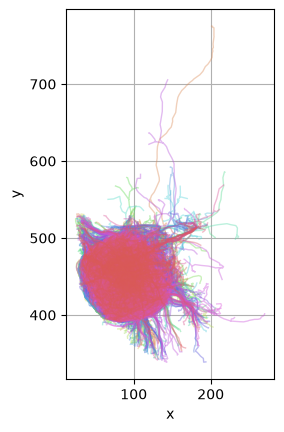

In [11]:
navis.plot2d(filtered_target_neurons, alpha=.4)

### Generate a color map for every unique type in dataset


In [12]:
class_counts = df_class_synced["classification_system"].value_counts(dropna=False)
class_probs = df_class_synced["classification_system"].value_counts(dropna=False, normalize=True)
print(class_counts)

unique_classes = df_class_synced["classification_system"].unique()
print(unique_classes)
print(len(unique_classes),"unique_classes")
palette = sns.color_palette("husl", len(unique_classes))
color_map = {t: mcolors.to_hex(palette[i]) for i, t in enumerate(unique_classes)}

classification_system
22A              91
03A              77
16B              71
13A              65
13B              43
04B              42
21A              39
14A              33
08A              28
19A              27
20A              26
09A              25
12B              24
01A              17
17A              13
23B              11
03B               9
01B               6
miscellaneous     6
11A               5
06B               2
unknown12B        1
19B               1
05B               1
Name: count, dtype: int64
['08A' '04B' '03A' '13A' '20A' '11A' '17A' '16B' '13B' '21A' 'unknown12B'
 '19A' 'miscellaneous' '03B' '22A' '09A' '01A' '14A' '12B' '23B' '01B'
 '19B' '06B' '05B']
24 unique_classes


Plot neurons:   0%|          | 0/663 [00:00<?, ?it/s]

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

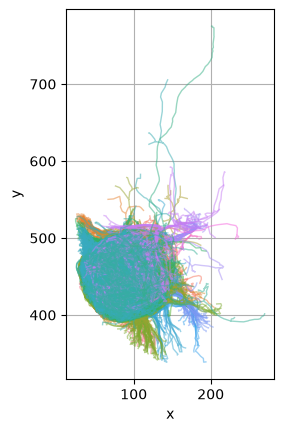

In [13]:
df_sorted = df_class_synced.sort_values(by="classification_system")

# 3. Use the sorted index permutation to rearrange the navis NeuronList
# df_sorted.index.values extracts the exact integer sequence needed to reorder the neurons
sorted_target_neurons = filtered_target_neurons[df_sorted.index.values]

# 4. Map the colors to match this new sorted order
sorted_neuron_colors = df_sorted["classification_system"].map(color_map).tolist()

# 5. CRITICAL: Reset the index of your sorted DataFrame 
# This keeps the DataFrame row indices (0, 1, 2...) permanently aligned with sorted_target_neurons
df_class_sorted = df_sorted.reset_index(drop=True)

name_to_class = dict(zip(df_sorted["SWC filename"], df_sorted["classification_system"]))
apply_name_to_class_map = np.vectorize(lambda x: name_to_class.get(x))

# 6. Plot the sorted, beautifully grouped population
navis.plot2d(sorted_target_neurons, color=sorted_neuron_colors, alpha=.5)

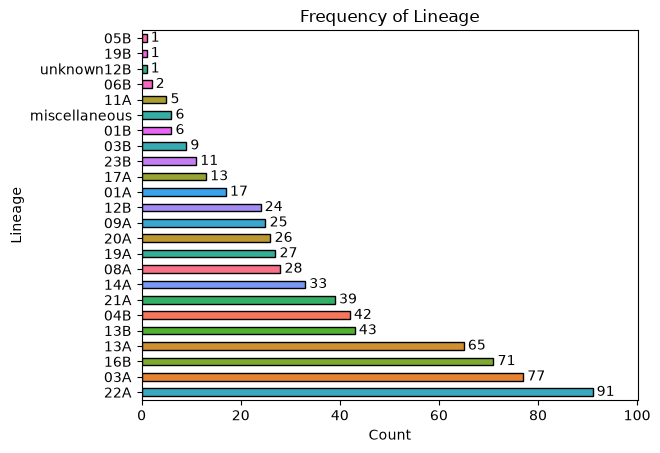

In [14]:
# A cleaner way to build your color list!
colors_list = [color_map.get(c) for c in class_counts.index]
    
# 1. Capture the plot in a variable called 'ax'
ax = class_counts.plot(kind='barh', color=colors_list, edgecolor='black')

# 2. Add the labels using the container holding the bars
# The 'padding' argument adds a little space between the bar and the number
ax.bar_label(ax.containers[0], padding=3)

plt.title('Frequency of Lineage')
plt.xlabel('Count')
plt.ylabel('Lineage')

# 3. Optional: Expand the x-axis limits slightly so the highest label isn't cut off
plt.margins(x=0.1) 

plt.show()

Plot neurons:   0%|          | 0/91 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/77 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/71 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/65 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/43 [00:00<?, ?it/s]

...

Plot neurons:   0%|          | 0/25 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/24 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/17 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/13 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/11 [00:00<?, ?it/s]

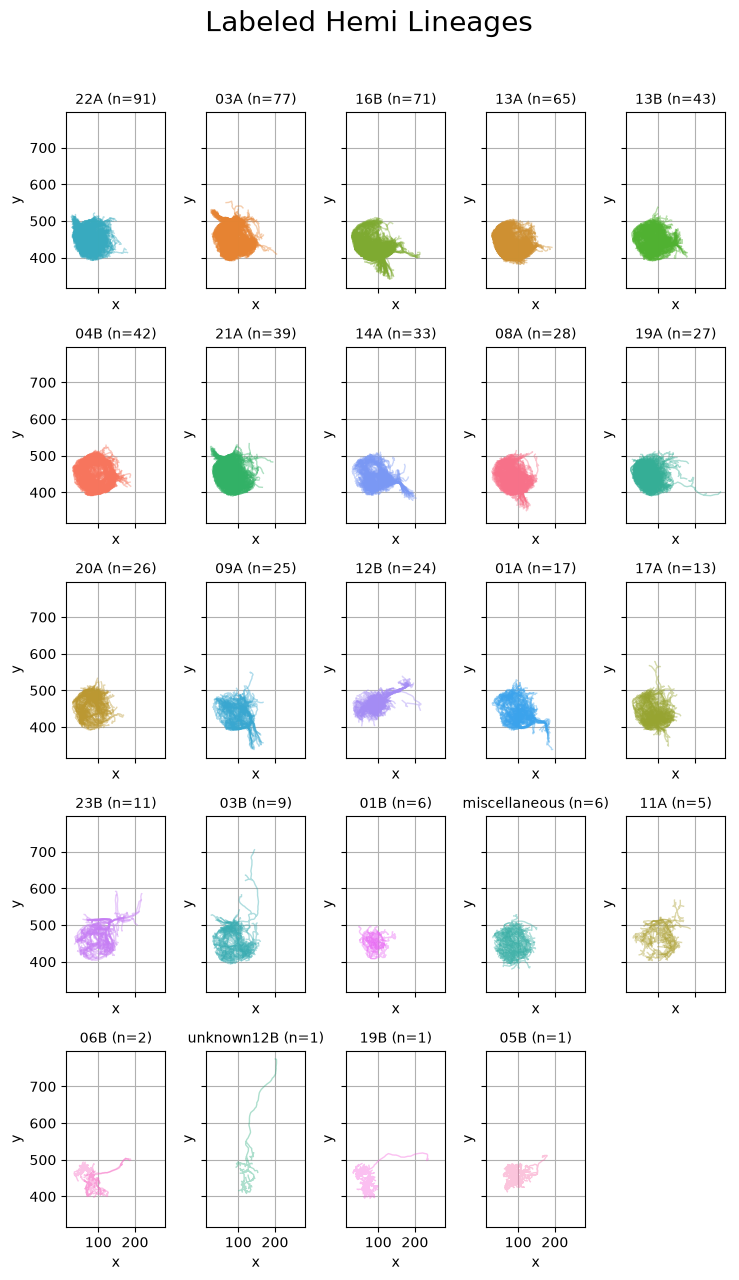

In [15]:
n_classes = len(unique_classes)

# FIX 1: Robust grid math that ALWAYS guarantees enough slots (num_rows * num_cols >= n_classes)
num_cols = int(np.ceil(np.sqrt(n_classes)))
num_rows = int(np.ceil(n_classes / num_cols))

# Dynamically scale the figure canvas based on the calculated grid shape
dims = (num_cols * 1.5, num_rows * 2.5)

fig, axs = plt.subplots(num_rows, num_cols, sharex='all', sharey='all', figsize=dims)

# FIX 2: Flatten the axes array into a 1D sequence. 
# np.atleast_1d ensures this works safely even if num_rows or num_cols equals 1.
axs_flat = np.atleast_1d(axs).flatten()

for i, t in enumerate(df_class_synced["classification_system"].value_counts().index):
    # Create a boolean filter mask for the current type
    class_mask = df_class_synced["classification_system"] == t
    temp_df = df_class_synced[class_mask]
    
    # Map using the global color_map
    subset_colors = temp_df["classification_system"].map(color_map).tolist()

    # FIX 3: Plot directly using the single 1D index 'i' instead of [r, c]
    navis.plot2d(
        filtered_target_neurons[class_mask.values], 
        color=subset_colors, 
        alpha=0.4, 
        ax=axs_flat[i]
    )
    
    axs_flat[i].set_title(f'{t} (n={len(filtered_target_neurons[class_mask.values])})', fontsize=10)

# FIX 4: Clean up and hide any empty trailing subplot boxes at the end of the grid
for j in range(n_classes, len(axs_flat)):
    axs_flat[j].axis('off')

fig.suptitle("Labeled Hemi Lineages", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

# Baseline


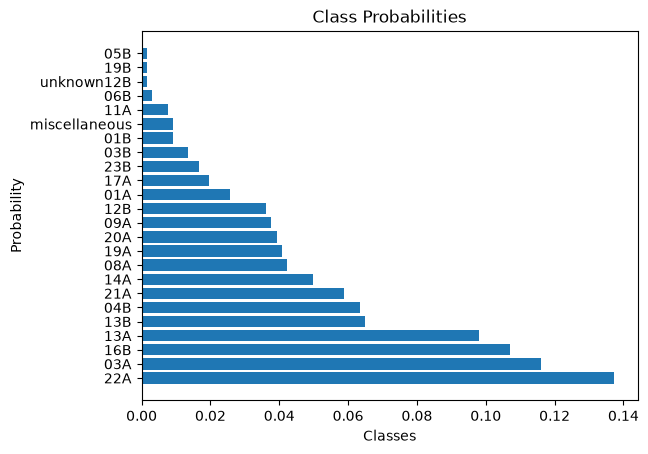

In [16]:
# 1. Correctly initialize figure and axes
fig, ax = plt.subplots()

# 2. Plot the bar chart using the axes object
ax.barh(class_probs.index, class_probs)

# 3. Add labels and a title (Optional but recommended)
ax.set_xlabel("Classes")
ax.set_ylabel("Probability")
ax.set_title("Class Probabilities")

# 4. Display the plot
plt.show()


In [17]:
unique_classes

array(['08A', '04B', '03A', '13A', '20A', '11A', '17A', '16B', '13B',
       '21A', 'unknown12B', '19A', 'miscellaneous', '03B', '22A', '09A',
       '01A', '14A', '12B', '23B', '01B', '19B', '06B', '05B'],
      dtype=object)

In [18]:
# df_class_sorted

baseline_accuracy_list = []

for _ in range(2000):

    baseline_pred = pd.Series(class_probs.index[np.random.choice(n_classes, size=df_class_sorted.shape[0], p=class_probs)])

    baseline_pred_probs = baseline_pred.value_counts(dropna=False, normalize=True)

    baseline_accuracy = ((df_class_sorted['classification_system'] == baseline_pred).sum()/df_class_sorted.shape[0])*100

    baseline_accuracy_list.append(baseline_accuracy)

# print(baseline_accuracy_list)

avg_baseline_accuracy = np.mean(baseline_accuracy_list)

print(f"Average Baseline Accuracy: {avg_baseline_accuracy:.2f}%")

Average Baseline Accuracy: 7.67%


In [19]:
# # 1. Correctly initialize figure and axes
# fig, ax = plt.subplots()

# # 2. Plot the bar chart using the axes object
# ax.barh(baseline_pred_probs.index, baseline_pred_probs)

# # 3. Add labels and a title (Optional but recommended)
# ax.set_xlabel("Classes")
# ax.set_ylabel("Probability")
# ax.set_title("Class Probabilities")

# # 4. Display the plot
# plt.show()


# NBLAST on FANC


## Convert to dotprops


In [20]:
target_dp = navis.make_dotprops(sorted_target_neurons)

Dotprops:   0%|          | 0/663 [00:00<?, ?it/s]

## All-pairs Forward NBLAST


In [21]:
raw_score_matrix = navis.nblast_allbyall(target_dp, n_cores=4, normalized=False)

Preparing:   0%|          | 0/1 [00:00<?, ?it/s]

NBlasting:   0%|          | 0/663 [00:00<?, ?it/s]

In [22]:
raw_score_matrix.head()

target,a6240850-cdfd-4052-b9b1-4bcc66a0e56e,a80314b6-488d-45ed-a271-69069dccb887,c3d89957-05a1-4b09-917b-44e19b301899,2432b1d2-4595-44e8-a340-0c4b994e8733,5f194c80-864e-4ef4-a566-40b284d52535,bc63a308-a7a6-41ef-9133-e621374bd188,59de7d7d-d677-4fd3-9a23-305836b94233,c94d1335-9fdf-4b12-90e2-337cb871a908,e008286c-25f1-442c-8f64-be43e5c89889,5b13f8cb-c85c-4e81-9777-adb58c6780af,...,281dc5e7-ef3b-4155-94dd-0f06b8a3755c,9038d619-462f-48a6-9ad7-cd9e921a6ea3,ad9e7ae5-1917-47fd-93f0-4b939d54b97d,92977be8-3560-418c-aa74-609e23ca6721,b1ab3912-31ca-47b6-889c-1d264faea8c2,b9600c8e-983a-4900-a539-3ca2569127c0,1f5161bb-db72-486f-a75a-e8cb4d0f9632,e1e6f2ca-d22f-4f8d-b1bb-3fb216d83c83,9674f0ff-9e01-424e-b0b8-87118d88e5de,7c18c4c2-f837-47c4-a232-c4f52ef2afe5
query,,,,,,,,,,,,,,,,,,,,,
a6240850-cdfd-4052-b9b1-4bcc66a0e56e,6309.633283,-2231.086807,1598.666995,-2301.971350,-865.663904,-1226.613560,-1077.159173,115.120743,-817.832330,-1909.055037,...,-3752.336184,-860.531928,-1584.523781,1284.796545,889.269420,735.346431,1411.822562,293.406876,27.713739,-3567.776626
a80314b6-488d-45ed-a271-69069dccb887,280.751945,1902.001369,809.398455,90.341809,789.286977,704.874062,-195.138537,1003.758042,-72.877674,287.074426,...,-100.275040,-162.364949,-88.058456,524.014022,150.919750,280.541375,178.116326,-484.928483,-96.941442,-1584.231544
c3d89957-05a1-4b09-917b-44e19b301899,1054.486154,523.683454,7653.562393,-305.494995,1671.910506,1352.799377,-1017.009396,1480.207770,-746.196664,-402.427828,...,-957.665149,-209.812586,235.088540,2649.395784,709.656009,1215.064576,1218.014113,-995.354746,645.657661,-5515.196216
2432b1d2-4595-44e8-a340-0c4b994e8733,273.251519,377.717465,626.702130,1560.324476,340.245701,290.132016,171.139091,691.487822,320.750918,609.181199,...,-543.396146,-302.574369,-104.650048,360.167054,173.454689,-67.225497,178.117010,-130.232748,81.763586,-1125.851455
5f194c80-864e-4ef4-a566-40b284d52535,-224.368482,928.714907,1710.227141,-1352.776302,6776.591702,2954.391568,-2736.667397,1322.775535,-1518.186339,-1509.694936,...,30.050267,68.245433,1191.658238,2383.090659,1837.131546,1893.637272,-351.527484,-1826.532503,-248.702193,-5898.544387


#### self-match normalization


In [23]:
score_matrix_self_normalized = raw_score_matrix.div(np.diag(raw_score_matrix), axis=0)

#### row-wise z-scoring


In [24]:
score_matrix_row_standardized = (raw_score_matrix.sub(raw_score_matrix.mean(axis=1), axis=0)).div(raw_score_matrix.std(axis=1), axis=0)

#### global z-scoring


In [25]:
score_matrix_global_standardized = (raw_score_matrix - raw_score_matrix.to_numpy().mean()) / raw_score_matrix.to_numpy().std()

In [26]:
matrix_dict = {
    "Raw": raw_score_matrix,
    "Self-Match Normalized": score_matrix_self_normalized,
    "Row Standardized": score_matrix_row_standardized,
    "Global Standardized": score_matrix_global_standardized,
    }

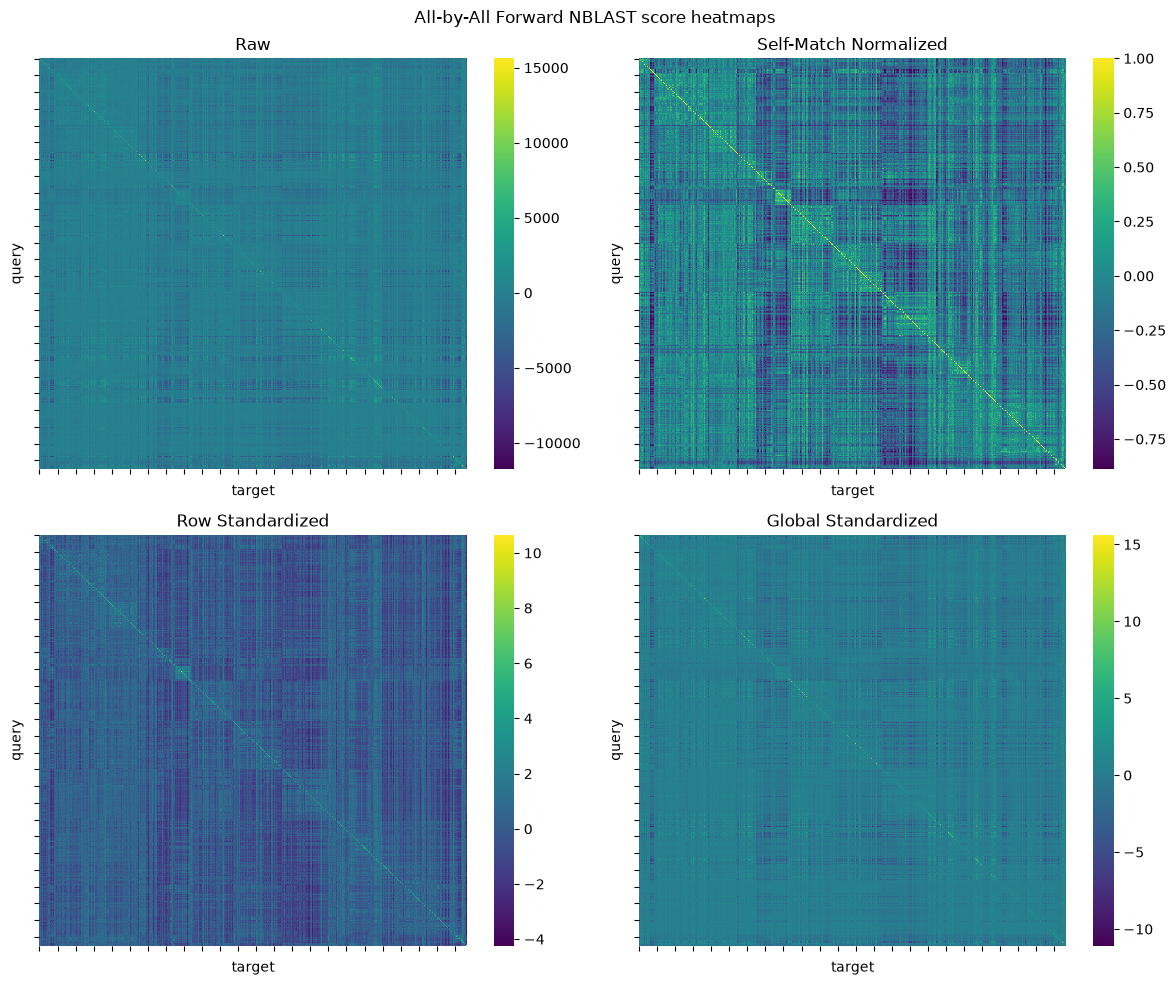

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

for i, (title, m) in enumerate(matrix_dict.items()):

    sns.heatmap(m,ax=axes[i],
        cmap="viridis",
    )
    
    axes[i].set_title(title)
    axes[i].set(xlabel="target", ylabel="query", xticklabels="", yticklabels="")

fig.suptitle("All-by-All Forward NBLAST score heatmaps")

plt.tight_layout()
plt.show()

## All-pairs Mean NBLAST


In [28]:
raw_score_matrix_mean = (raw_score_matrix + raw_score_matrix.T)/2
score_matrix_self_normalized_mean = (score_matrix_self_normalized + score_matrix_self_normalized.T)/2
score_matrix_row_standardized_mean = (score_matrix_row_standardized + score_matrix_row_standardized.T)/2
score_matrix_global_standardized_mean = (score_matrix_global_standardized + score_matrix_global_standardized.T)/2

In [29]:
mean_matrix_dict = {
    "Raw": raw_score_matrix_mean,
    "Self-Match Normalized": score_matrix_self_normalized_mean,
    "Row Standardized": score_matrix_row_standardized_mean,
    "Global Standardized": score_matrix_global_standardized_mean
    }

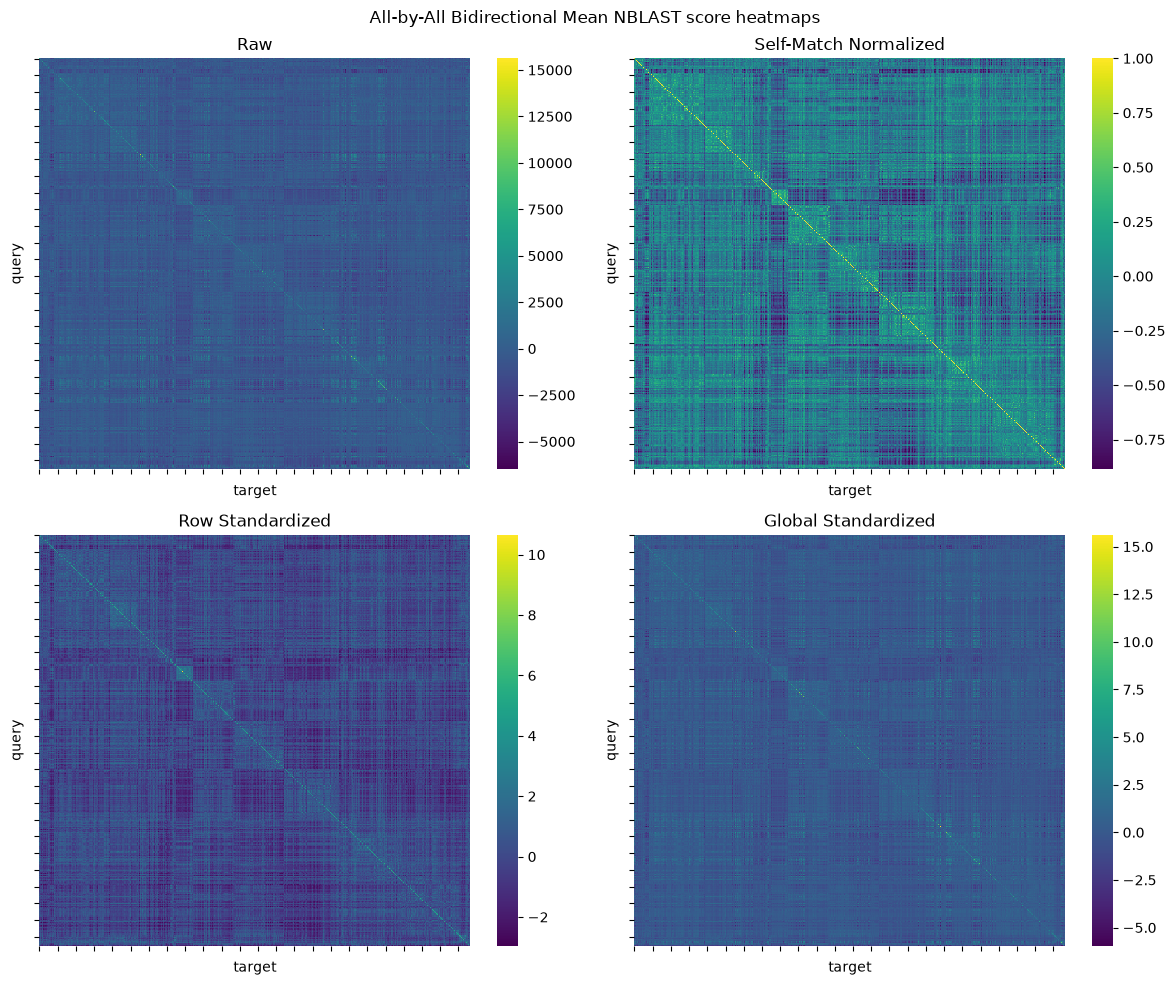

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

for i, (title, m) in enumerate(mean_matrix_dict.items()):

    sns.heatmap(m,ax=axes[i],
        cmap="viridis",
    )
    
    axes[i].set_title(title)
    axes[i].set(xlabel="target", ylabel="query", xticklabels="", yticklabels="")
    
fig.suptitle("All-by-All Bidirectional Mean NBLAST score heatmaps")

plt.tight_layout()
plt.show()

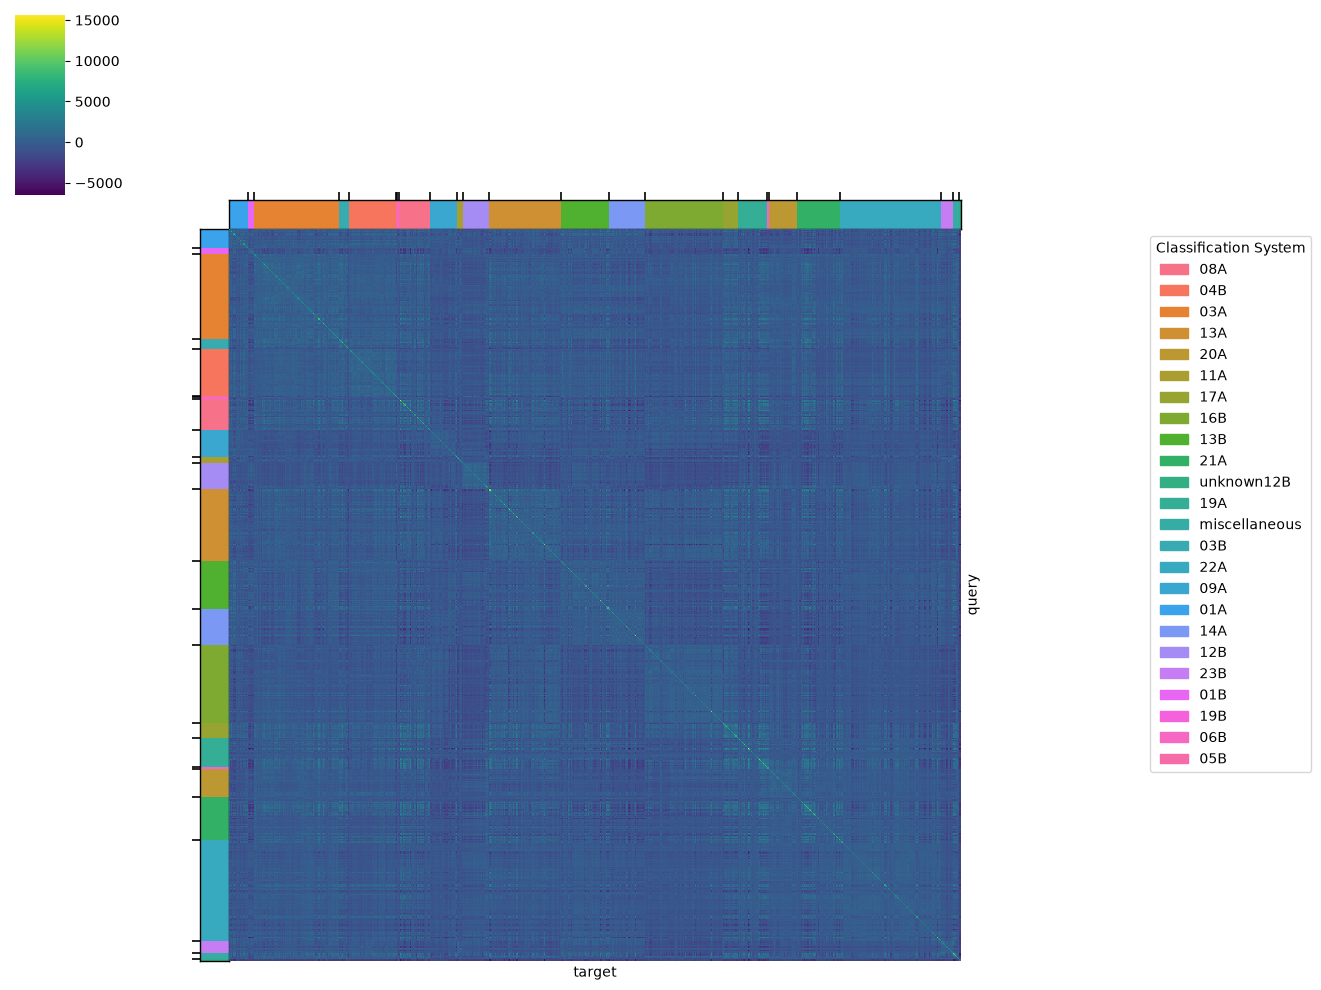

In [31]:
# 1. Map the sorted dataframe classifications to their hex colors
color_track = df_class_sorted["classification_system"].map(color_map).tolist()

# 2. Plot using clustermap with clustering features turned OFF
g = sns.clustermap(
    mean_matrix_dict['Raw'],
    row_cluster=False,  # Keep manual type-sorting intact
    col_cluster=False,  # Keep manual type-sorting intact
    row_colors=color_track,  # Vertical color bar
    col_colors=color_track,  # Horizontal color bar
    xticklabels=False,  # Keep main matrix clean
    yticklabels=False,
    cmap="viridis",
)

# 3. Dynamically find the exact matrix indices where classes change
categories = df_class_sorted["classification_system"].values
boundaries = np.where(categories[:-1] != categories[1:])[0] + 1

# =====================================================================
# 4. CONFIGURE TICK MARKS ON THE TOP (COLUMN) COLOR BAR
# =====================================================================
g.ax_col_colors.set_xticks(boundaries)
g.ax_col_colors.set_xticklabels([])  # No text labels, just ticks

# Make ticks point outward on both the top and bottom edge of the bar
g.ax_col_colors.tick_params(
    axis="x",
    which="both",
    direction="out",
    length=6,
    width=1.2,
    color="black",
    bottom=True,
    top=True,
)

# Encase the bar in a clean frame outline so the ticks have an anchor line
for spine in g.ax_col_colors.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.0)


# =====================================================================
# 5. CONFIGURE TICK MARKS ON THE LEFT (ROW) COLOR BAR
# =====================================================================
g.ax_row_colors.set_yticks(boundaries)
g.ax_row_colors.set_yticklabels([])  # No text labels, just ticks

# Make ticks point outward on both the left and right edge of the bar
g.ax_row_colors.tick_params(
    axis="y",
    which="both",
    direction="out",
    length=6,
    width=1.2,
    color="black",
    left=True,
    right=True,
)

# Encase the bar in a clean frame outline
for spine in g.ax_row_colors.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.0)


# 6. Add your custom legend safely outside the plot area
legend_handles = [
    mpatches.Patch(color=color, label=label) for label, color in color_map.items()
]
g.ax_heatmap.legend(
    handles=legend_handles,
    title="Classification System",
    bbox_to_anchor=(1.25, 1.0),
    loc="upper left",
)

plt.show()

## K Score-weighted Majority Vote


In [32]:
test_actual_lineage_list, test_predicted_lineage_list, _, _ = top_k_infer_lineage_fast(mean_matrix_dict['Raw'], k=3)

pd.DataFrame(test_predicted_lineage_list)[0].value_counts(dropna=False)

0
19A              108
13A               92
14A               53
22A               52
13B               48
21A               47
16B               46
03A               41
08A               40
04B               24
09A               23
12B               21
01A               13
23B               12
miscellaneous      9
20A                9
17A                6
05B                6
03B                5
11A                5
01B                3
Name: count, dtype: int64

Tuning Raw:   0%|          | 0/9 [00:00<?, ?it/s]

Raw -> Best k = 8, Accuracy: 63.35%


Tuning Self-Match Normalized:   0%|          | 0/9 [00:00<?, ?it/s]

Self-Match Normalized -> Best k = 4, Accuracy: 78.88%


Tuning Row Standardized:   0%|          | 0/9 [00:00<?, ?it/s]

Row Standardized -> Best k = 1, Accuracy: 78.28%


Tuning Global Standardized:   0%|          | 0/9 [00:00<?, ?it/s]

Global Standardized -> Best k = 8, Accuracy: 63.50%


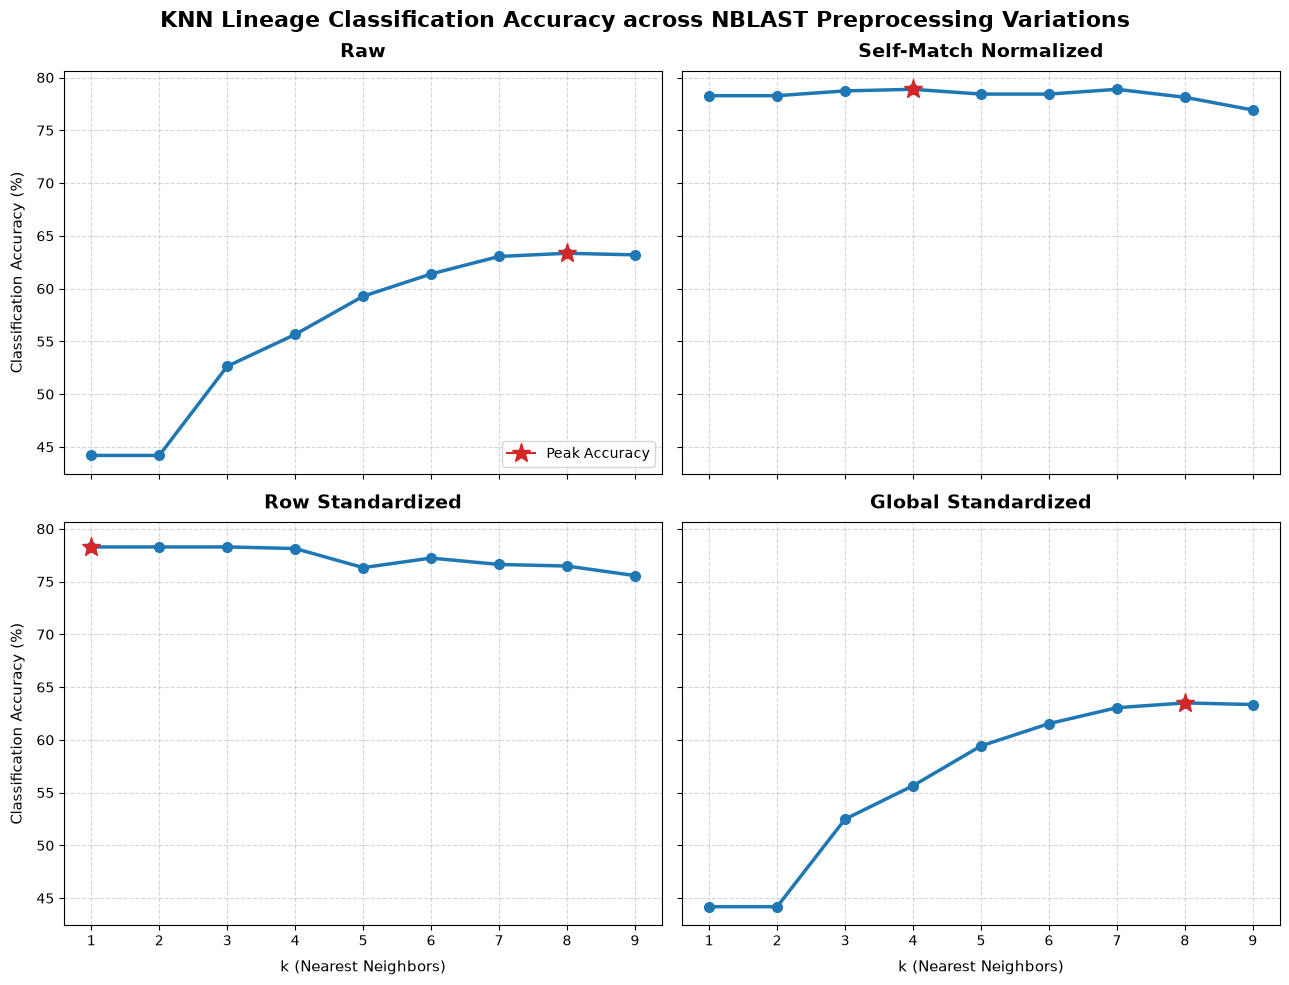

In [33]:
evaluate_and_plot_knn(mean_matrix_dict, df_class_synced, k_values=range(1, 10))

### Confusion Matrix


In [34]:
def metrix_breakdown(actual_lineage_list, predicted_lineage_list, matrix_title, k):
    # 1. Combine your actual and predicted results into a temporary DataFrame for easy grouping
    df_performance = pd.DataFrame({
        'Actual': actual_lineage_list,
        'Predicted': predicted_lineage_list
    })

    # 2. Compute the total count for each true class
    # class_counts = df_performance['Actual'].value_counts()

    # 3. Compute the accuracy per class (True Positives / Total for that class)
    df_performance['Is_Correct'] = df_performance['Actual'] == df_performance['Predicted']
    class_accuracy = df_performance.groupby('Actual')['Is_Correct'].mean() * 100

    # 4. Merge them into a single summary DataFrame and sort by Count descending
    summary_df = pd.DataFrame({
        'Count': class_counts,
        'Accuracy': class_accuracy
    }).fillna(0).sort_values(by='Count', ascending=False)

    # 5. Dynamically scale the figure height based on how many classes you have
    # This keeps the text from overlapping whether you have 5 classes or 40!
    fig_height = max(6, len(summary_df) * 0.2)
    fig, axes = plt.subplots(1, 2, figsize=(16, fig_height), sharey=True)

    # =====================================================================
    # Left Plot: Class Counts
    # =====================================================================
    sns.barplot(
        x='Count', 
        y=summary_df.index, 
        data=summary_df, 
        ax=axes[0], 
        palette='dark:#1f77b4',
        hue=summary_df.index,  # Keeps seaborn happy regarding upcoming deprecations
        legend=False
    )
    axes[0].set_title('Dataset Class Distribution (True Counts)', fontsize=14, pad=15)
    axes[0].set_xlabel('Number of Neurons', fontsize=12)
    axes[0].set_ylabel('Lineage / Class System', fontsize=12)
    axes[0].grid(True, axis='x', linestyle='--', alpha=0.4)

    # FIX 2: Add distinct horizontal guide rails running through the middle of every row
    axes[0].grid(True, axis='y', linestyle=':', color='gray', alpha=0.7, linewidth=1)

    # Add integer text labels to the end of each count bar
    for p in axes[0].patches:
        width = p.get_width()
        if width > 0:  # Skip drawing if count is 0
            axes[0].annotate(
                f' {int(width)}', 
                (width, p.get_y() + p.get_height() / 2),
                va='center', ha='left', fontsize=9, weight='bold'
            )

    # =====================================================================
    # Right Plot: Per-Class Accuracy
    # =====================================================================
    sns.barplot(
        x='Accuracy', 
        y=summary_df.index, 
        data=summary_df, 
        ax=axes[1], 
        palette='dark:#2ca02c',
        hue=summary_df.index,
        legend=False
    )
    axes[1].set_title('Model Accuracy Per Class', fontsize=14, pad=15)
    axes[1].set_xlabel('Accuracy (%)', fontsize=12)
    axes[1].set_xlim(0, 115)  # Leave room for the percentage labels text
    axes[1].grid(True, axis='x', linestyle='--', alpha=0.4)

    # FIX 2: Add distinct horizontal guide rails running through the middle of every row
    axes[1].grid(True, axis='y', linestyle=':', color='gray', alpha=0.7, linewidth=1)

    # Add percentage text labels to the end of each accuracy bar
    for p in axes[1].patches:
        width = p.get_width()
        axes[1].annotate(
            f' {width:.1f}%', 
            (width, p.get_y() + p.get_height() / 2),
            va='center', ha='left', fontsize=9, weight='bold'
        )


    # Force all y-axis tick labels to be visible
    for ax in fig.axes:
        ax.tick_params(axis='y', labelleft=True)
        
    # 6. Final layout touches
    fig.suptitle(f"{matrix_title} NBLAST Lineage Metrics Breakdown (k={k} | Overall Accuracy: {accuracy:.2%})", fontsize=16, weight='bold', y=0.98)
    # fig.suptitle(f"NBLAST Lineage Inference Confusion Matrix (k={k} | Overall Accuracy: {accuracy:.2%})", fontsize=20)

    plt.tight_layout()
    plt.show()

## Bayesian approach


In [36]:
# # Initialize class model with your custom color mapping


# for title in matrix_dict:
#     bayes_model = BayesianNBLASTClassifier(color_map=color_map, default_color='gray')
    
#     m = matrix_dict.get(title).copy()

#     # 1. Double check that the matrix and metadata have the exact same number of neurons
#     if len(m) == len(df_class_synced):
        
#         # 2. Overwrite the random NBLAST UUIDs with the actual Metadata IDs
#         m.index = df_class_synced.index
#         m.columns = df_class_synced.index

#     # Fit priors and normal density distributions
#     bayes_model.fit(m, df_class_synced)

#     # Run classification predictions across all targets
#     test_ids = m.index.tolist()
#     predictions, probabilities = bayes_model.predict_map(
#         query_ids = test_ids,
#         score_matrix = m,
#         metadata = df_class_synced
#         )
    
#     predicted_vals = predictions["Predicted_Class"].values
#     actual_vals = df_class_synced["classification_system"].values
    
#     # Calculate accuracy
#     correct_count = (predicted_vals == actual_vals).sum()
#     accuracy = correct_count / len(actual_vals)
#     # ---------------
    
#     bayes_model.plot_predictions(
#         predictions, 
#         title=f"Frequency of Bayesian Predicted Lineages\n(Forward {title} Scores) | {correct_count} correct | {accuracy*100:.2f}% accuracy"
#     )
    

In [37]:
# # Initialize class model with your custom color mapping


# for title in mean_matrix_dict:
#     bayes_model = BayesianNBLASTClassifier(color_map=color_map, default_color='gray')
    
#     m = mean_matrix_dict.get(title).copy()
    
#     # 1. Double check that the matrix and metadata have the exact same number of neurons
#     if len(m) == len(df_class_synced):
        
#         # 2. Overwrite the random NBLAST UUIDs with the actual Metadata IDs
#         m.index = df_class_synced.index
#         m.columns = df_class_synced.index

#     # Fit priors and normal density distributions
#     bayes_model.fit(m, df_class_synced)
    
#     # Run classification predictions across all targets
#     test_ids = m.index.tolist()
#     predictions, probabilities = bayes_model.predict_map(
#         query_ids = test_ids,
#         score_matrix = m,
#         metadata = df_class_synced
#         )
    
#     predicted_vals = predictions["Predicted_Class"].values
#     actual_vals = df_class_synced["classification_system"].values
    
#     # Calculate accuracy
#     correct_count = (predicted_vals == actual_vals).sum()
#     accuracy = correct_count / len(actual_vals)
#     # ---------------
    
#     bayes_model.plot_predictions(
#         predictions, 
#         title=f"Frequency of Bayesian Predicted Lineages\n(Mean {title} Scores) | {correct_count} correct | {accuracy*100:.2f}% accuracy"
#     )
    


--- Running Bayesian Pipeline for: Raw ---


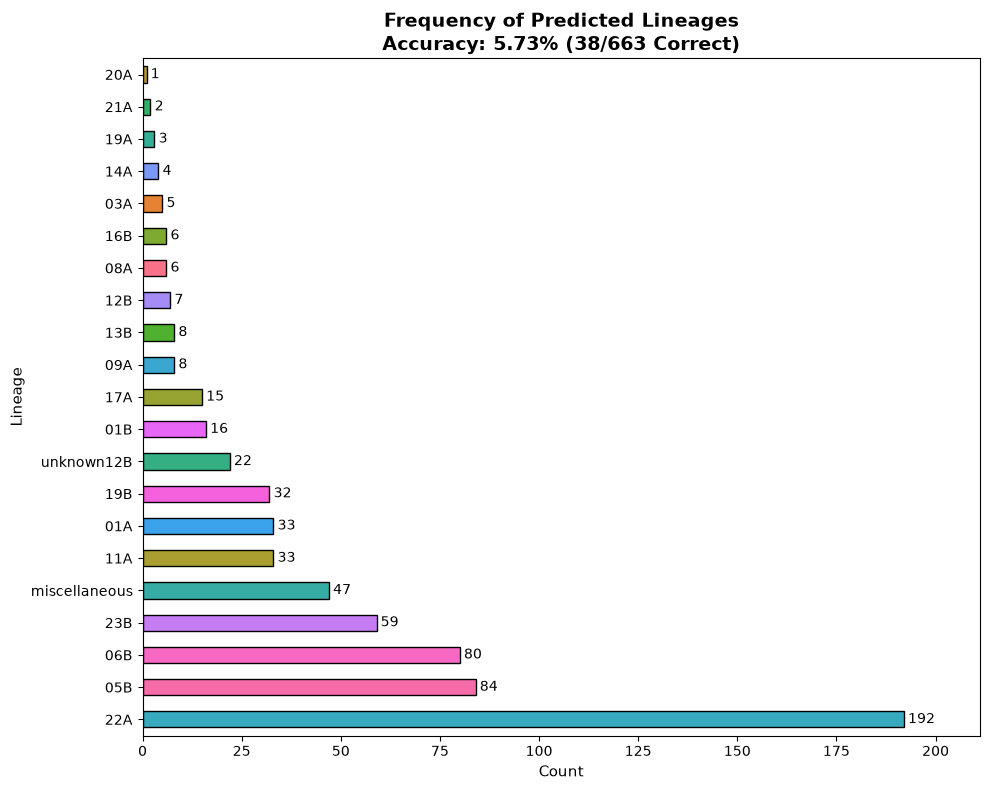


--- Running Bayesian Pipeline for: Self-Match Normalized ---


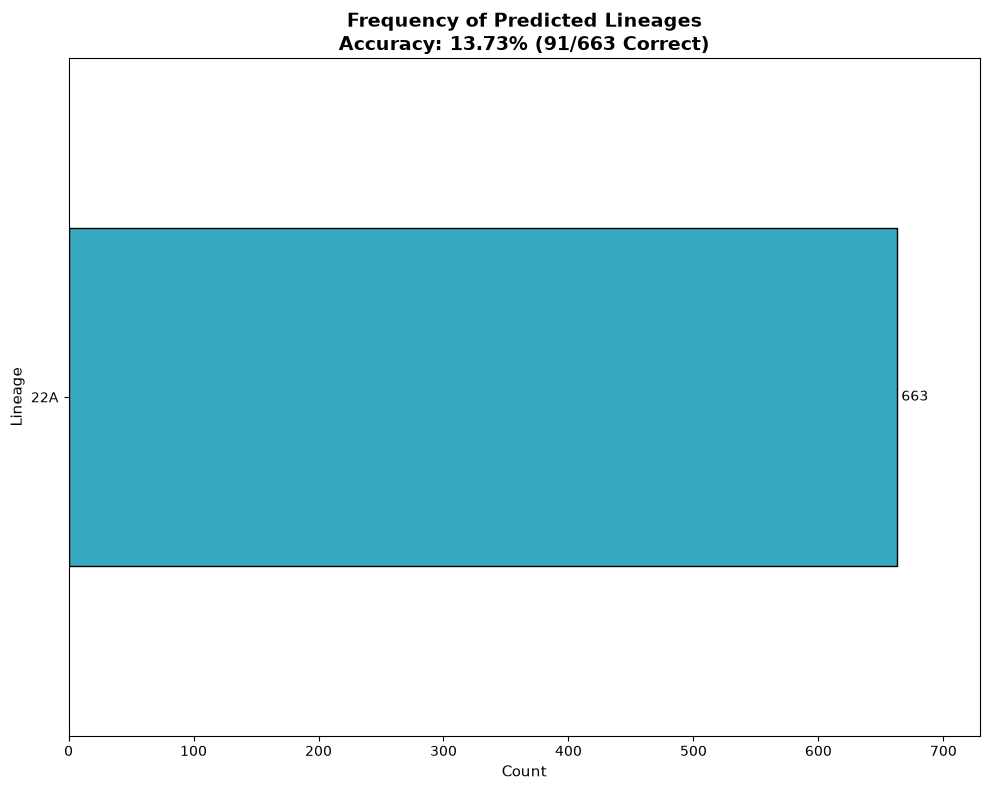


--- Running Bayesian Pipeline for: Row Standardized ---


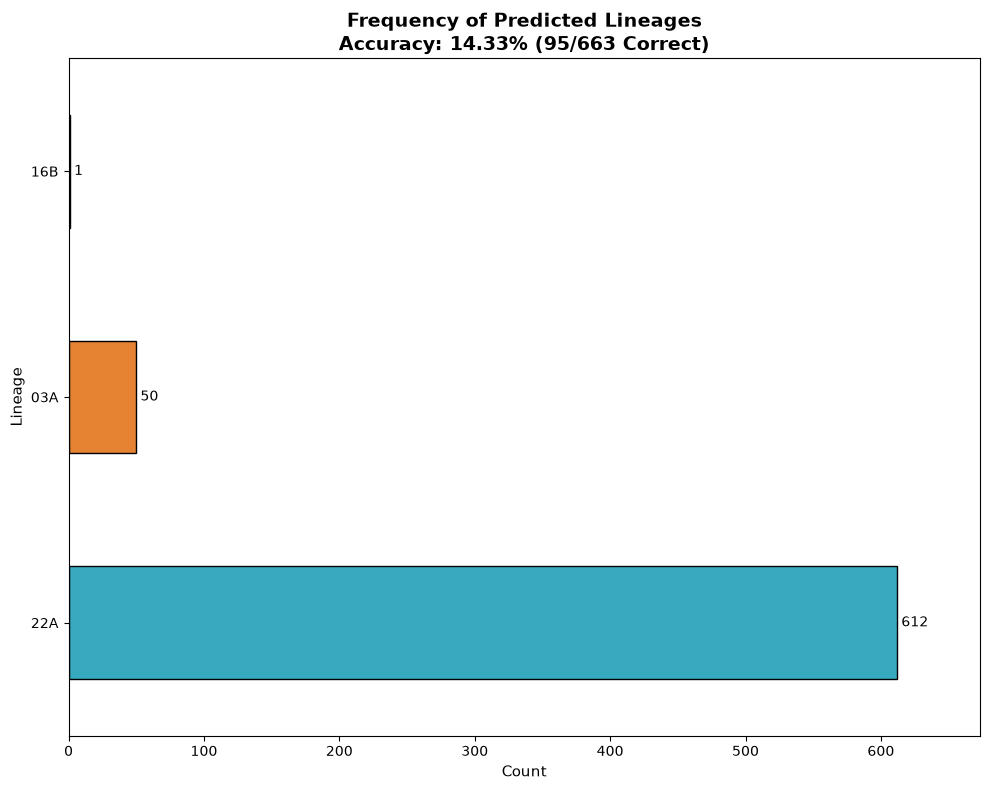


--- Running Bayesian Pipeline for: Global Standardized ---


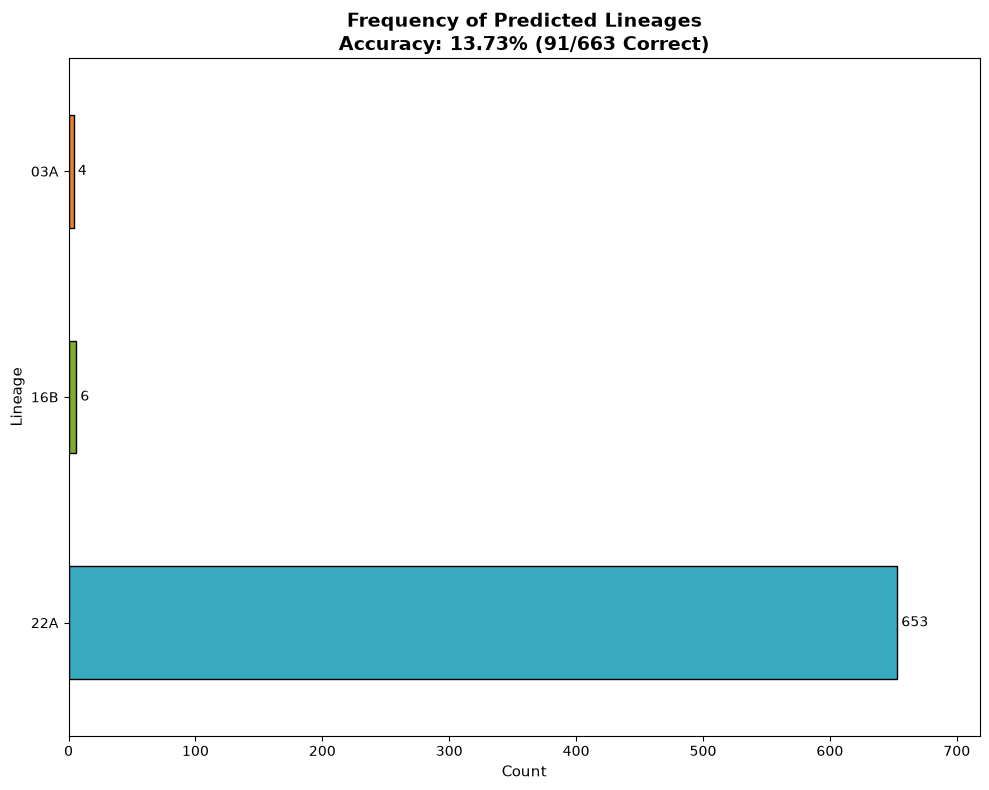

In [66]:
# Loop through all your preprocessed matrices
for title in matrix_dict:
    
    m = matrix_dict.get(title).copy()
    
    # 1. Double check that the matrix and metadata have the exact same number of neurons
    if len(m) == len(df_class_synced):
        # 2. Overwrite the random NBLAST UUIDs with the actual Metadata IDs
        m.index = df_class_synced.index
        m.columns = df_class_synced.index

    # Initialize the class model by passing your metadata dependencies
    bayes_model = BayesianNBLASTClassifier(
        name_to_class=name_to_class,
        sorted_target_neurons=sorted_target_neurons,
        df_class_synced=df_class_synced,
        unique_classes=unique_classes,
        color_map=color_map,
        default_color='gray'
    )
    
    # Run the internal pipeline (executes math, calculates accuracy, and shows the plot)
    print(f"\n--- Running Bayesian Pipeline for: {title} ---")
    predictions, probabilities = bayes_model.run_bayesian(score_matrix=m)


--- Running Bayesian Pipeline for: Raw ---


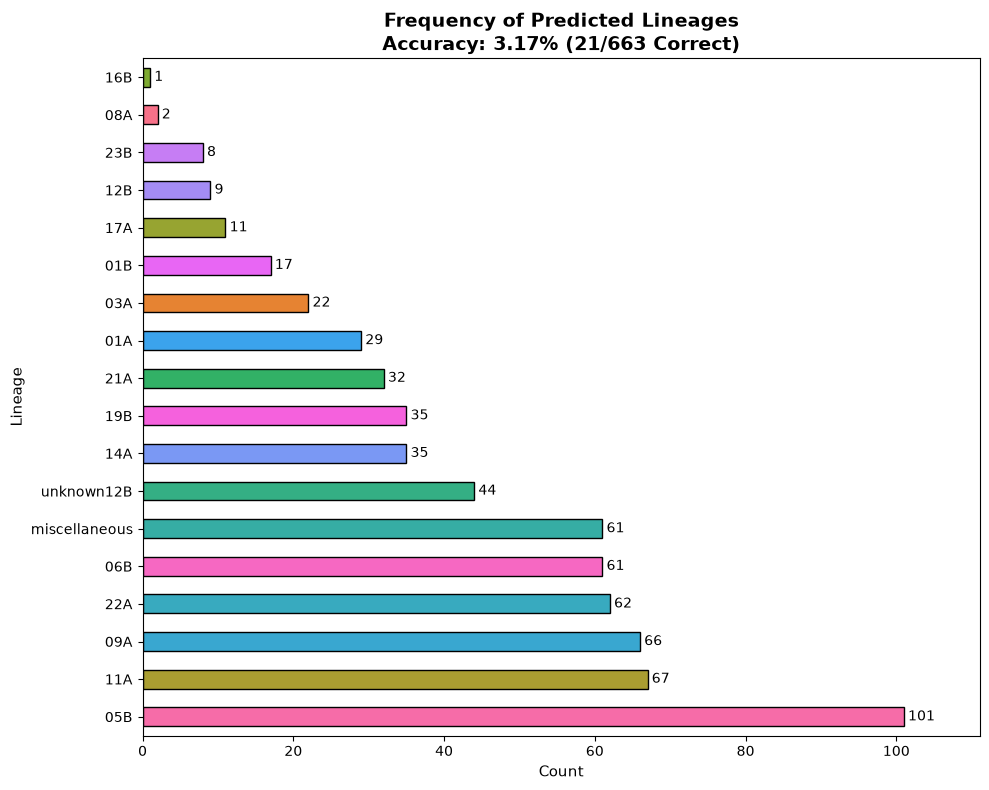


--- Running Bayesian Pipeline for: Self-Match Normalized ---


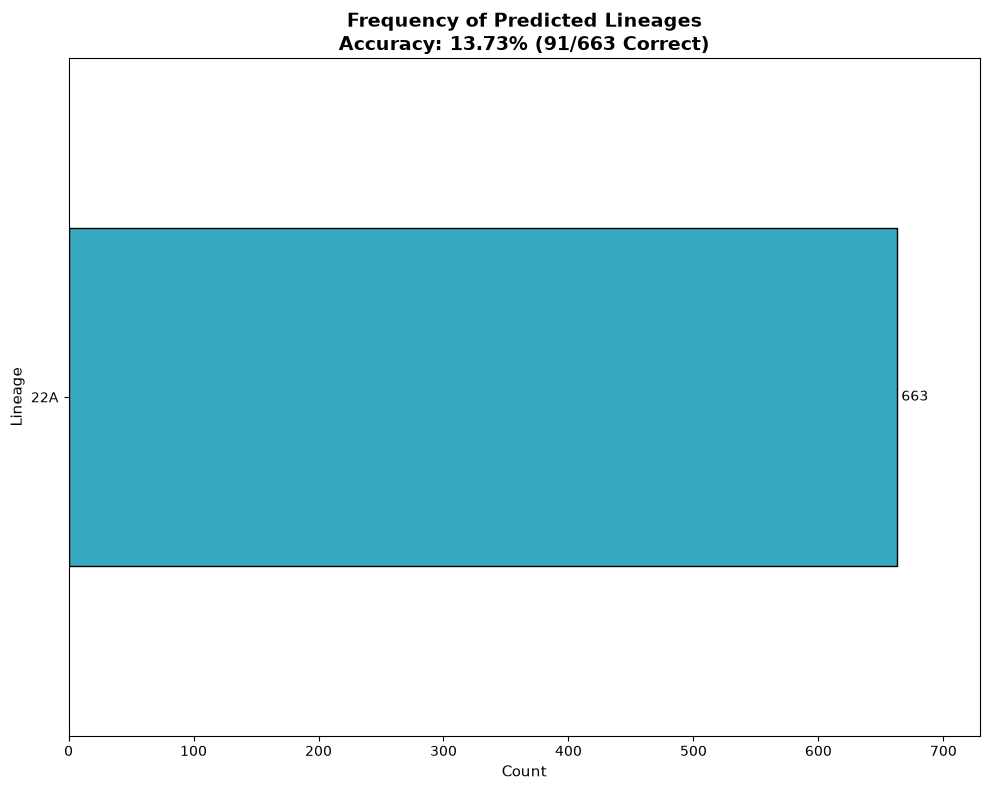


--- Running Bayesian Pipeline for: Row Standardized ---


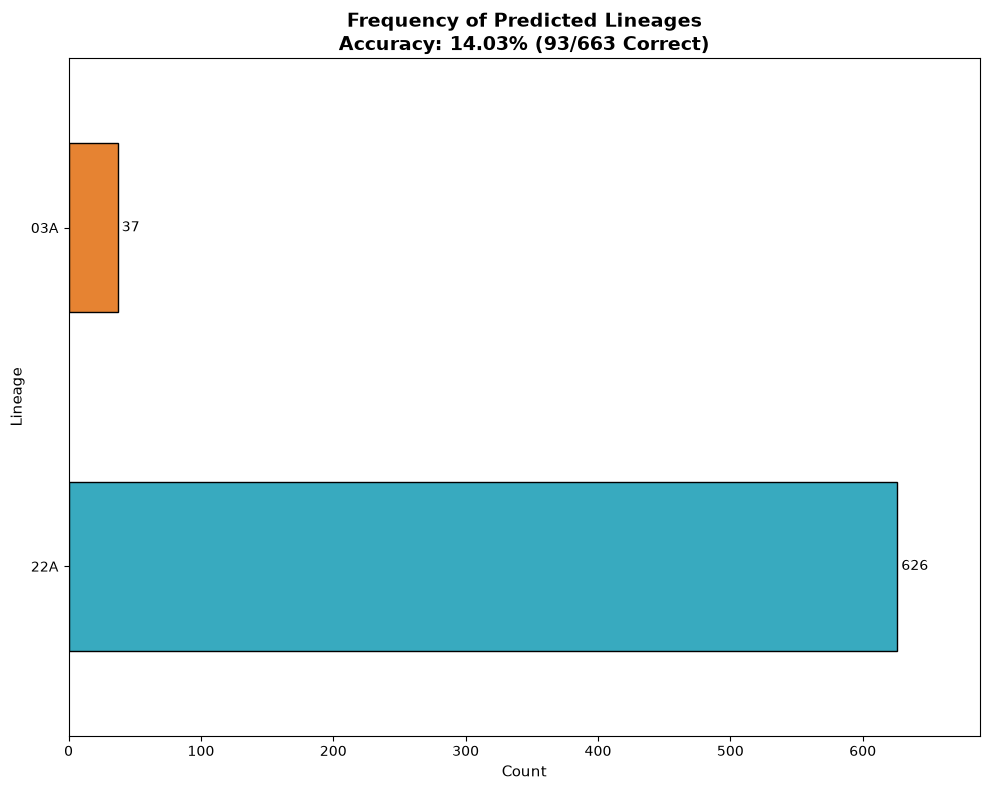


--- Running Bayesian Pipeline for: Global Standardized ---


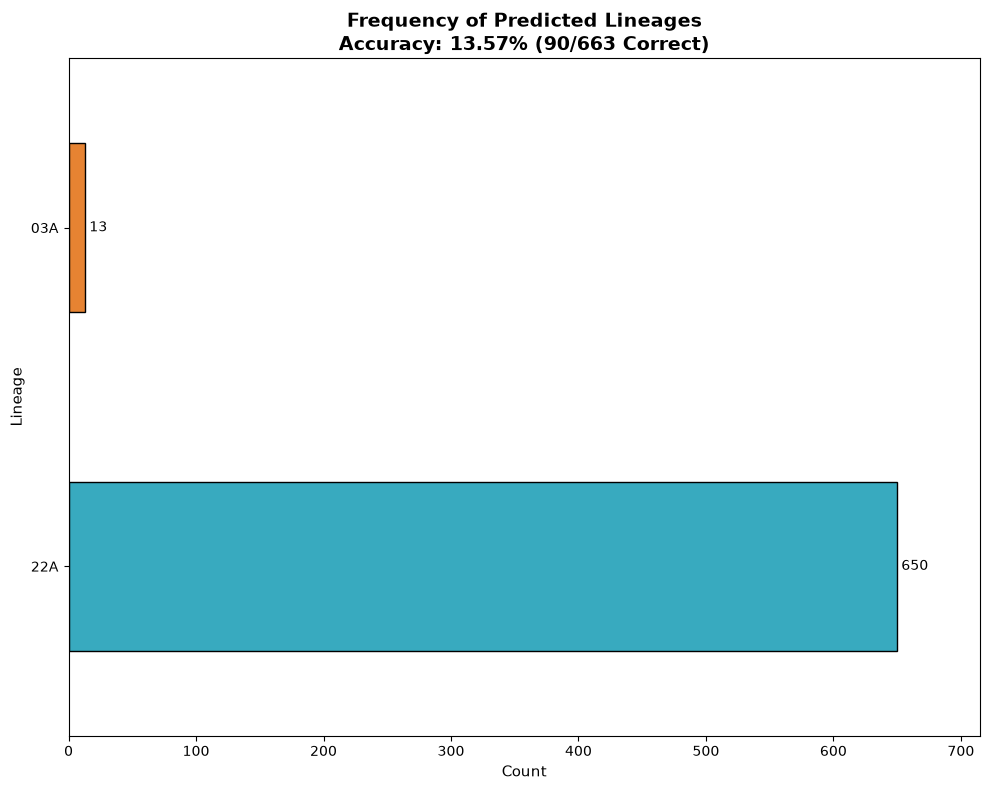

In [65]:
# Loop through all your preprocessed matrices
for title in mean_matrix_dict:
    
    m = mean_matrix_dict.get(title).copy()
    
    # 1. Double check that the matrix and metadata have the exact same number of neurons
    if len(m) == len(df_class_synced):
        # 2. Overwrite the random NBLAST UUIDs with the actual Metadata IDs
        m.index = df_class_synced.index
        m.columns = df_class_synced.index

    # Initialize the class model by passing your metadata dependencies
    bayes_model = BayesianNBLASTClassifier(
        name_to_class=name_to_class,
        sorted_target_neurons=sorted_target_neurons,
        df_class_synced=df_class_synced,
        unique_classes=unique_classes,
        color_map=color_map,
        default_color='gray'
    )
    
    # Run the internal pipeline (executes math, calculates accuracy, and shows the plot)
    print(f"\n--- Running Bayesian Pipeline for: {title} ---")
    predictions, probabilities = bayes_model.run_bayesian(score_matrix=m)

    likelihood_func=min_max_scale_likelihood



--- Running Bayesian Pipeline for: Raw ---


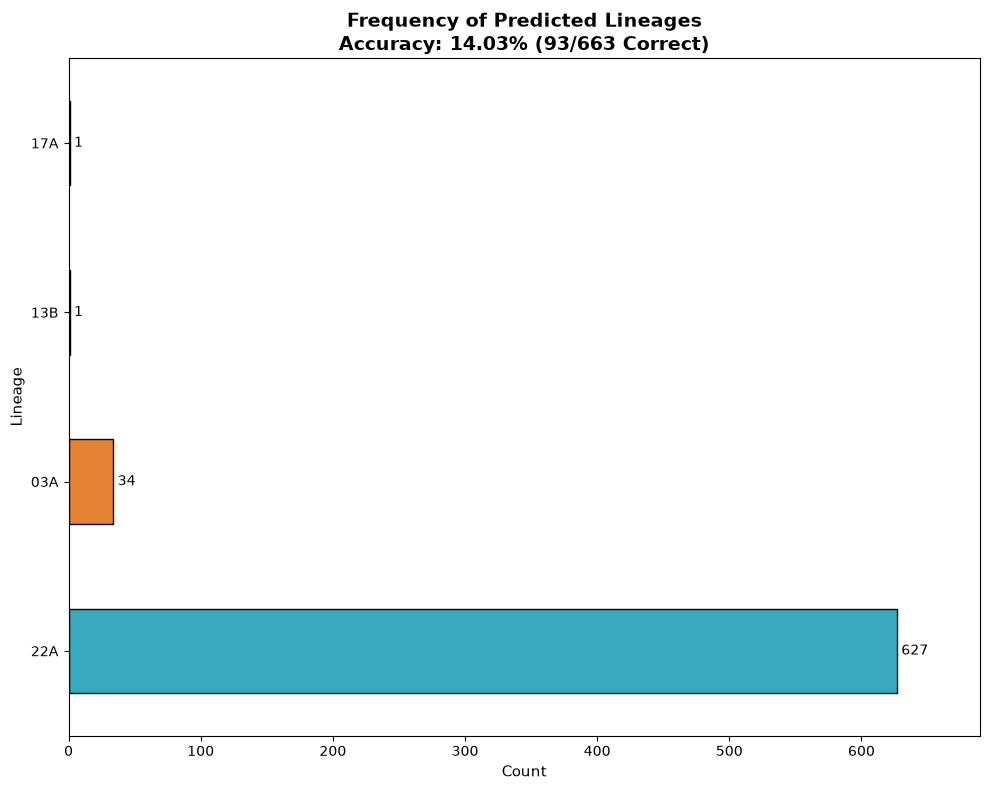


--- Running Bayesian Pipeline for: Self-Match Normalized ---


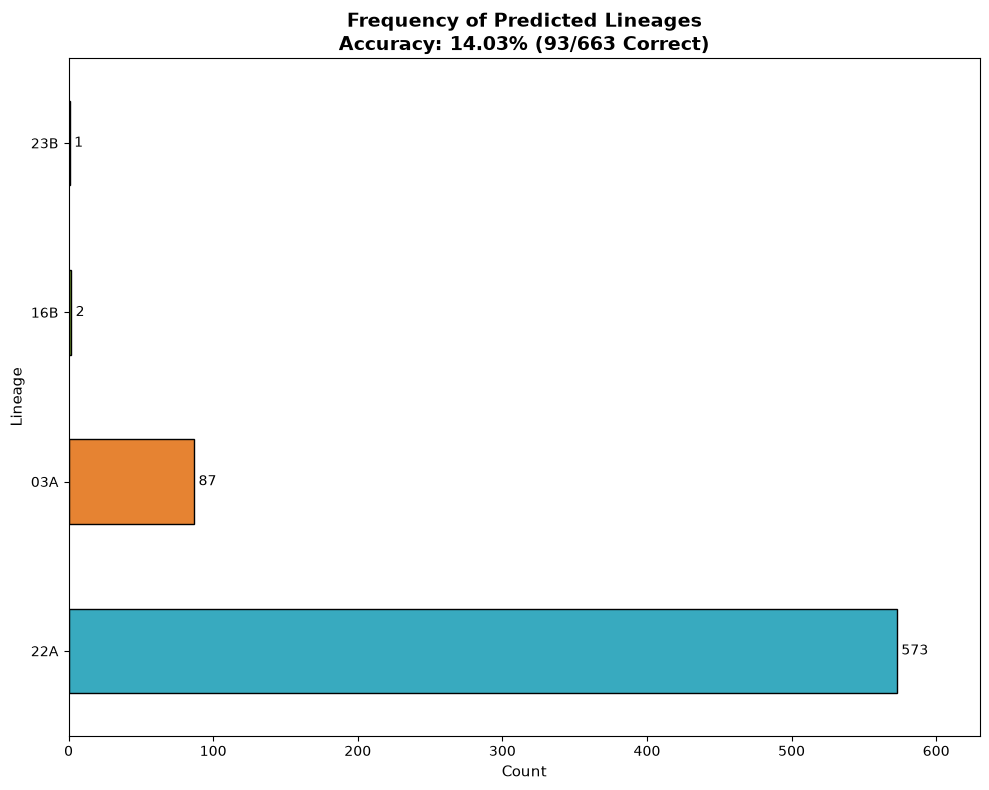


--- Running Bayesian Pipeline for: Row Standardized ---


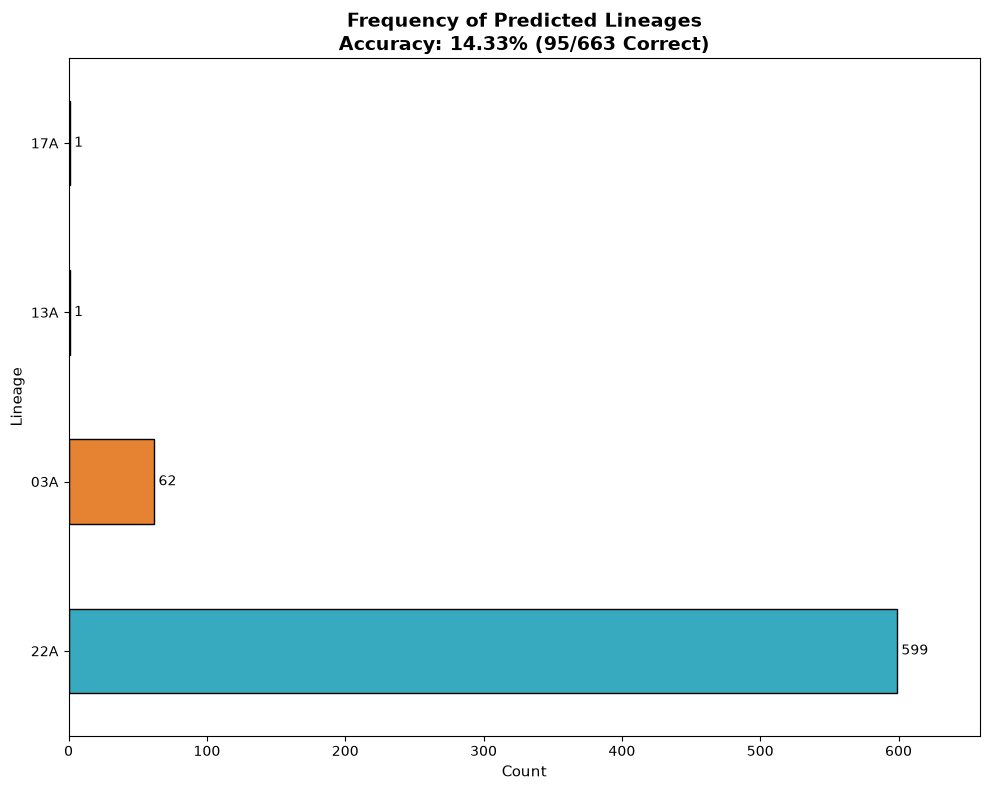


--- Running Bayesian Pipeline for: Global Standardized ---


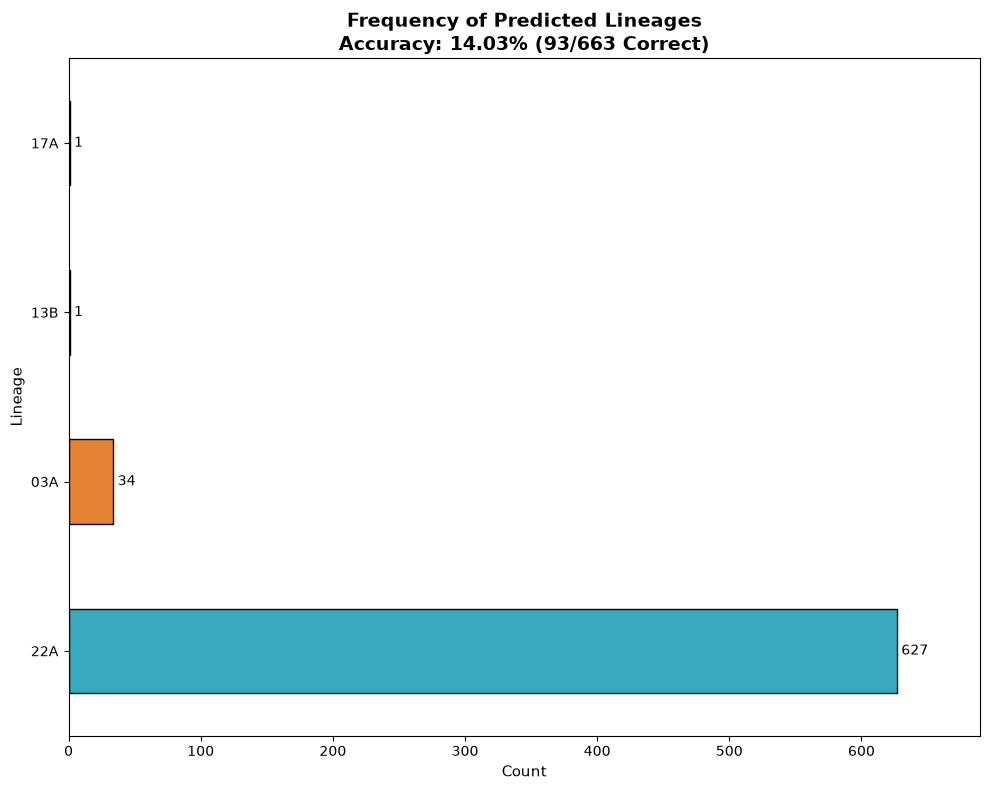

In [67]:
# Define your experimental math function
def min_max_scale_likelihood(df):
    return (df - df.min()) / (df.max() - df.min())


# Loop through all your preprocessed matrices
for title in matrix_dict:
    
    m = matrix_dict.get(title).copy()
    
    # 1. Double check that the matrix and metadata have the exact same number of neurons
    if len(m) == len(df_class_synced):
        # 2. Overwrite the random NBLAST UUIDs with the actual Metadata IDs
        m.index = df_class_synced.index
        m.columns = df_class_synced.index
    
    # Initialize the class model by passing your metadata dependencies
    bayes_model = BayesianNBLASTClassifier(
        name_to_class=name_to_class,
        sorted_target_neurons=sorted_target_neurons,
        df_class_synced=df_class_synced,
        unique_classes=unique_classes,
        color_map=color_map,
        default_color='gray',
        likelihood_func=min_max_scale_likelihood
    )
    # Run the internal pipeline (executes math, calculates accuracy, and shows the plot)
    print(f"\n--- Running Bayesian Pipeline for: {title} ---")
    predictions, probabilities = bayes_model.run_bayesian(score_matrix=m)


--- Running Bayesian Pipeline for: Raw ---


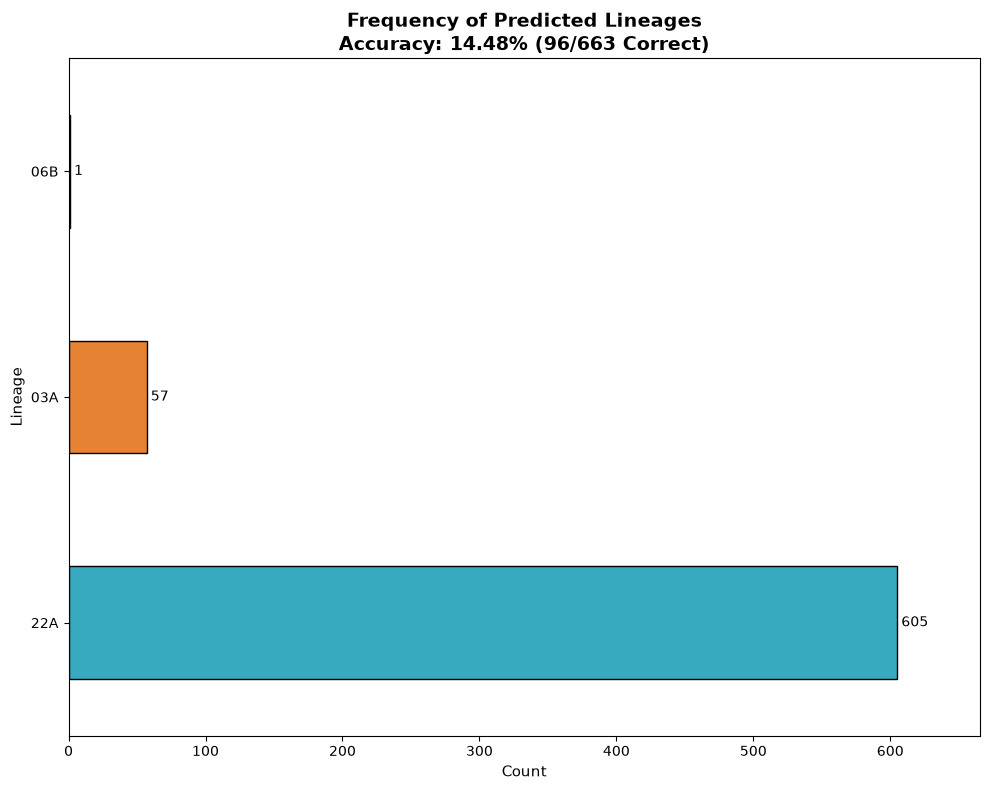


--- Running Bayesian Pipeline for: Self-Match Normalized ---


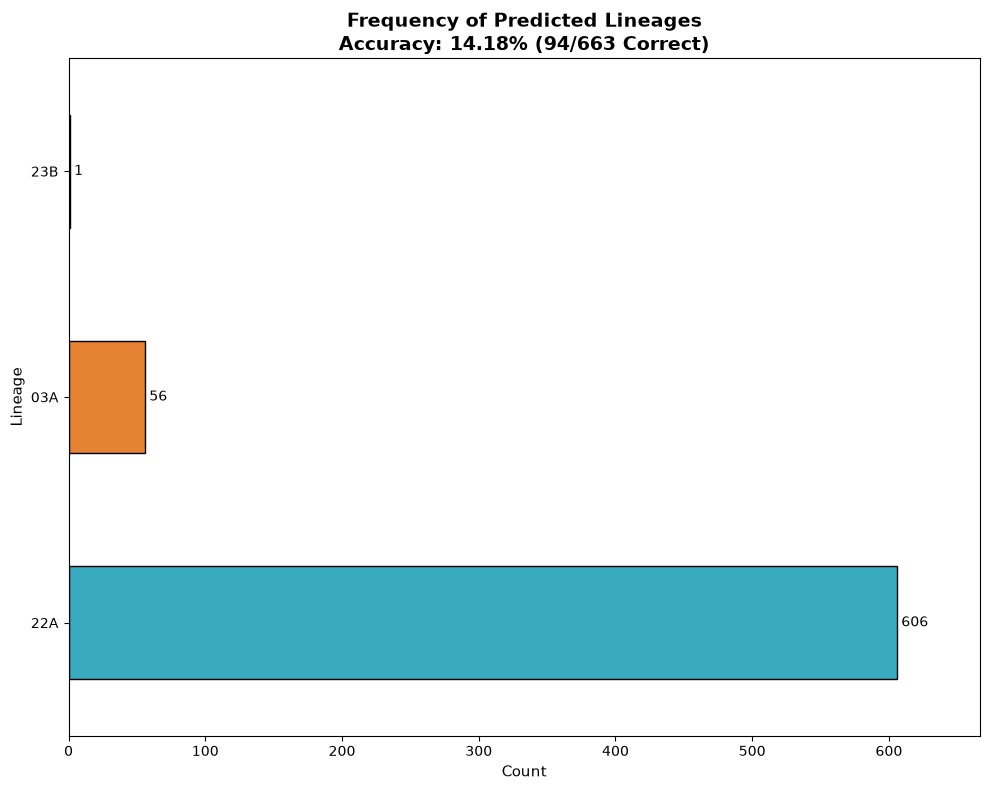


--- Running Bayesian Pipeline for: Row Standardized ---


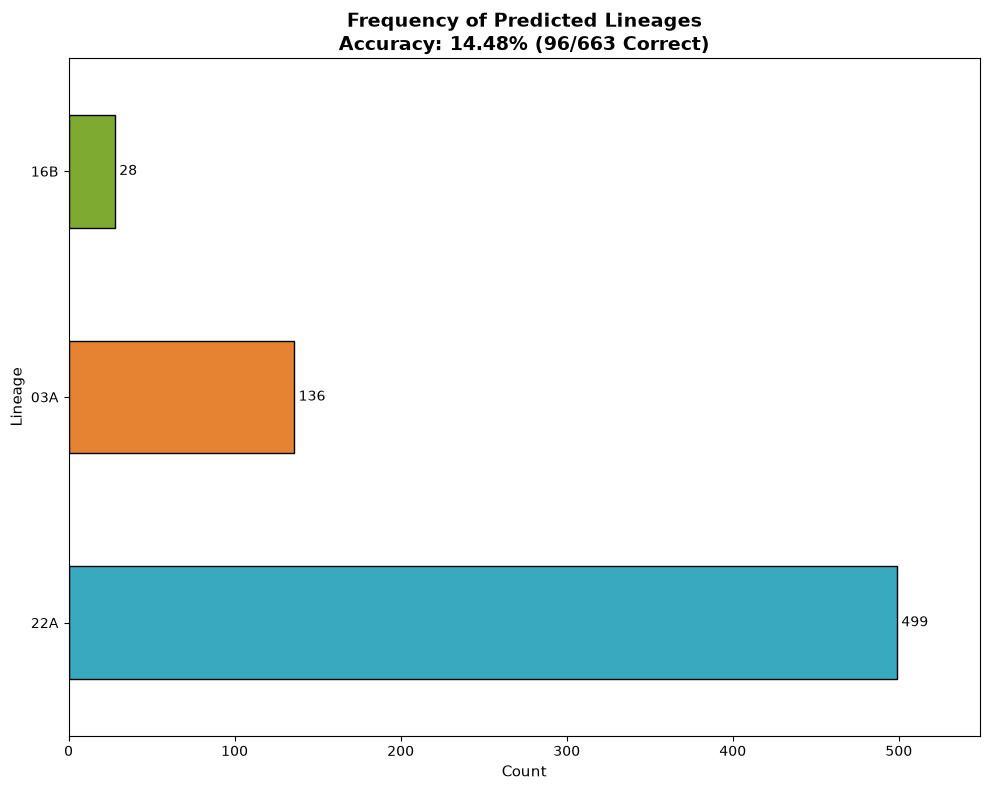


--- Running Bayesian Pipeline for: Global Standardized ---


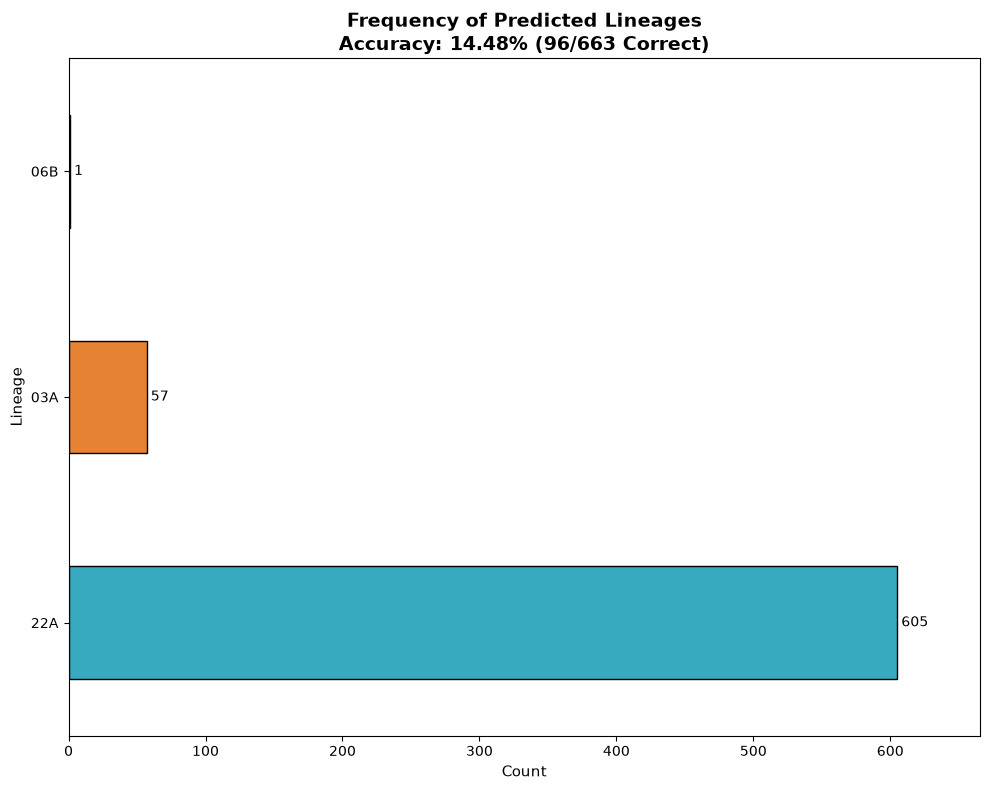

In [68]:
# Loop through all your preprocessed matrices
for title in mean_matrix_dict:
    
    m = mean_matrix_dict.get(title).copy()
    
    # 1. Double check that the matrix and metadata have the exact same number of neurons
    if len(m) == len(df_class_synced):
        # 2. Overwrite the random NBLAST UUIDs with the actual Metadata IDs
        m.index = df_class_synced.index
        m.columns = df_class_synced.index
        
    # Initialize the class model by passing your metadata dependencies
    bayes_model = BayesianNBLASTClassifier(
        name_to_class=name_to_class,
        sorted_target_neurons=sorted_target_neurons,
        df_class_synced=df_class_synced,
        unique_classes=unique_classes,
        color_map=color_map,
        default_color='gray',
        likelihood_func=min_max_scale_likelihood
    )
    
    # Run the internal pipeline (executes math, calculates accuracy, and shows the plot)
    print(f"\n--- Running Bayesian Pipeline for: {title} ---")
    predictions, probabilities = bayes_model.run_bayesian(score_matrix=m)